<a href="https://colab.research.google.com/github/amandageol/Landslides-Susceptibility-and-Triggering-Rainfall---Machine-Learning-and-Statistical-Methods/blob/LSM-branch/6rev_lsm_grid_5m.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q geopandas
!pip install -q rasterio

# Common imports
import numpy as np
import os
import numpy as np
from osgeo import gdal
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio as rio
import glob
import matplotlib.pyplot as plt
from shapely.ops import unary_union
from shapely.geometry import Point
pd.options.display.float_format = '{:.4f}'.format

import random
random.seed(123)

EPSG:31983


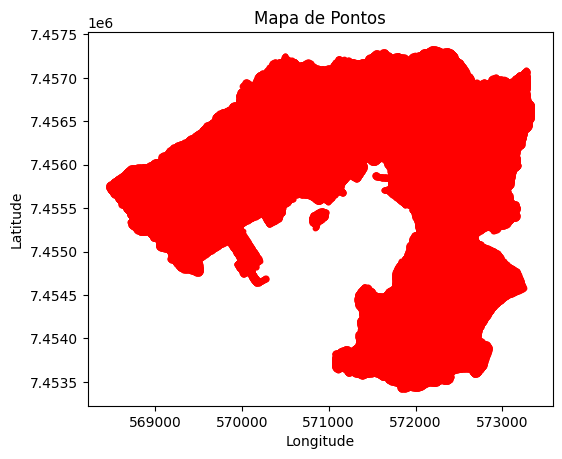

Mínimos:
id                  1102.0000
Soils                  1.0000
Lithology              0.0000
TWI                    1.0000
Profile_Curvature      1.0000
Plan_Curvature         1.0000
Curvature              1.0000
DEM                    1.0000
Slope                  1.0000
NDVI                   1.0000
NDBI                   1.0000
Aspect                 1.0000
dtype: float64

Máximos:
id                  764747.0000
Soils                  255.0000
Lithology                3.0000
TWI                    127.0000
Profile_Curvature      127.0000
Plan_Curvature         127.0000
Curvature              127.0000
DEM                  65535.0000
Slope                  127.0000
NDVI                   127.0000
NDBI                   127.0000
Aspect               32767.0000
dtype: float64


In [ ]:
# Carregar o shapefile com os pontos
points_FC_norm = gpd.read_file('/content/drive/MyDrive/dados tese/grids/5m.shp')

# Carregar os arquivos raster
rasters_norm = glob.glob('/content/drive/MyDrive/dados tese/fatores condicionantes classificados/*.tif')

# Converter geometrias MultiPoint para Point (caso necessário)
points_FC_norm['geometry'] = points_FC_norm['geometry'].apply(lambda mp: Point(unary_union(mp)))
print(points_FC_norm.crs)

# Amostrar valores dos rasters para os pontos
for raster_name in rasters_norm:
    column_name = os.path.splitext(os.path.basename(raster_name))[0]  # Nome da coluna sem extensão
    with rasterio.open(raster_name) as src:
        array = src.read(1)  # Ler a primeira banda do raster
        transform = src.transform  # Transformação do raster para coordenadas

        # Converter coordenadas dos pontos para índices do raster
        indices = [
            ~transform * (point.x, point.y)
            for point in points_FC_norm["geometry"]
        ]

        # Extrair valores com base nos índices
        points_FC_norm[column_name] = [
            array[int(row), int(col)] if 0 <= int(row) < array.shape[0] and 0 <= int(col) < array.shape[1] else np.nan
            for col, row in indices
        ]

# Plotar os pontos no mapa
fig, ax = plt.subplots(figsize=(6, 6))
points_FC_norm.plot(ax=ax, color='red', markersize=10)

# Adicionar título e rótulos aos eixos
plt.title('Mapa de Pontos')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Exibir o mapa
plt.show()

# Selecionar apenas colunas numéricas, excluindo a coluna geométrica
numeric_columns = points_FC_norm.select_dtypes(include=['number'])

# Mostrar o mínimo e máximo de todas as colunas numéricas
print("Mínimos:")
print(numeric_columns.min())

print("\nMáximos:")
print(numeric_columns.max())

In [ ]:
# Definindo os valores indesejados para cada coluna
valores_indesejados = {
    'Soils': 255,
    'DEM': 65535,
    'NDVI': 127,
    'Slope': 127,
    'Aspect': 32767,
    'NDBI': 127,
    'Lithology': 0,
    'Plan_Curvature': 127,
    'TWI': 127
}

# Substituindo os valores indesejados por NaN
for coluna, valor in valores_indesejados.items():
    points_FC_norm[coluna] = points_FC_norm[coluna].replace(valor, np.nan)

In [ ]:
# Verificar se existem valores NaN em qualquer coluna de points_FC_norm
nan_values_before = points_FC_norm.isna().sum()

# Exibir a quantidade de NaN antes da remoção
print("Quantidade de NaN antes da remoção:")
print(nan_values_before)

# Remover as linhas que contêm NaN em qualquer coluna
points_FC_norm_clean = points_FC_norm.dropna()

# Verificar novamente se sobram NaN após a remoção
nan_values_after = points_FC_norm_clean.isna().sum()

# Exibir a quantidade de NaN após a remoção
print("Quantidade de NaN após a remoção:")
print(nan_values_after)

# Exibir a tabela de pontos limpos
print(points_FC_norm_clean)

Quantidade de NaN antes da remoção:
id                      0
geometry                0
Soils                7209
Lithology            7209
TWI                  3985
Profile_Curvature     194
Plan_Curvature       4007
Curvature             194
DEM                  3985
Slope                3985
NDVI                 3477
NDBI                 3477
Aspect               3985
dtype: int64
Quantidade de NaN após a remoção:
id                   0
geometry             0
Soils                0
Lithology            0
TWI                  0
Profile_Curvature    0
Plan_Curvature       0
Curvature            0
DEM                  0
Slope                0
NDVI                 0
NDBI                 0
Aspect               0
dtype: int64
            id                        geometry  Soils  Lithology    TWI  \
0         1102  POINT (568467.877 7455760.944) 8.0000     3.0000 6.0000   
1         1103  POINT (568467.877 7455755.944) 8.0000     3.0000 6.0000   
2         1104  POINT (568467.877 7455750.

EPSG:31983


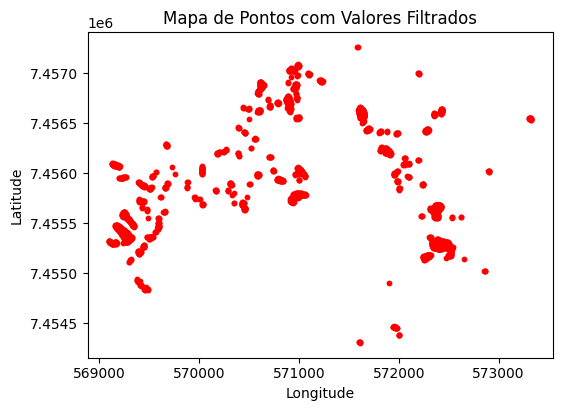

,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,NDVI,NDBI,Aspect,VALUE
0,100100,POINT (569097.877 7455320.944),4,3,1,1,8,8,6,8,8,1,5,1
1,100101,POINT (569097.877 7455315.944),4,3,1,1,8,8,6,8,8,1,5,1
2,100885,POINT (569102.877 7455320.944),4,3,1,1,8,8,6,8,8,1,5,1
3,100886,POINT (569102.877 7455315.944),4,3,1,1,8,8,6,8,8,1,5,1
4,100887,POINT (569102.877 7455310.944),4,3,1,1,8,8,6,8,8,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3334,763181,POINT (573322.877 7456540.944),7,2,2,1,8,8,8,4,4,4,7,1
3335,763182,POINT (573322.877 7456535.944),7,2,2,1,8,8,8,4,6,4,7,1
3336,763965,POINT (573327.877 7456545.944),7,2,2,1,8,8,8,4,4,4,7,1
3337,763966,POINT (573327.877 7456540.944),7,2,2,1,8,8,8,4,4,4,7,1


In [ ]:
# Carregando o arquivo de pontos (GeoDataFrame)
occ = gpd.read_file('/content/drive/MyDrive/dados tese/grids/pontos cicatrizes 2010 a 2021.shp')
print(occ.crs)

# Convertendo geometrias MultiPoint para Point
occ['geometry'] = occ['geometry'].apply(lambda mp: Point(unary_union(mp)))

# Definindo os valores indesejados para cada coluna em 'occ'
valores_indesejados_occ = {
    'Soils': 255,
    'DEM': 65535,
    'NDVI': 127,
    'Slope': 127,
    'Aspect': 32767,
    'NDBI': 127,
    'Lithology': 0,
    'Plan_Curvature': 127,
    'TWI': 127
}

# Substituindo os valores indesejados por NaN nas colunas de 'occ'
for coluna, valor in valores_indesejados_occ.items():
    if coluna in occ.columns:
        occ[coluna] = occ[coluna].replace(valor, np.nan)

# Continuar com o código para amostrar os valores do raster nos locais dos pontos
# Supondo que 'rasters_norm' seja uma lista de caminhos para os arquivos raster (não definida aqui)
# Exemplo de como amostrar os valores do raster:
for raster_path in rasters_norm:  # Rasters devem estar definidos
    with rio.open(raster_path) as raster:
        file_name = os.path.basename(raster_path)  # Obter o nome do arquivo TIFF
        column_name = os.path.splitext(file_name)[0]  # Obter o nome do arquivo sem a extensão
        occ[column_name] = [sample[0] for sample in raster.sample(zip(occ['geometry'].x, occ['geometry'].y))]

# Plotando os pontos filtrados com valores NaN
fig, ax = plt.subplots(figsize=(6, 6))
occ.plot(ax=ax, color='red', markersize=10)

# Adicionar título e rótulos aos eixos
plt.title('Mapa de Pontos com Valores Filtrados')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Exibir o mapa
plt.show()

occ['VALUE'] = 1

# Visualizar o GeoDataFrame após a substituição de valores indesejados por NaN
occ

EPSG:31983


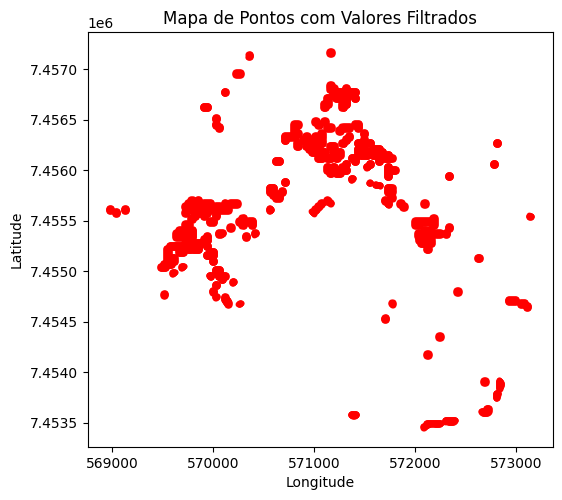

,SAMPLE_1,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,NDVI,NDBI,Aspect,VALUE
0,1,POINT (568962.877 7455625.944),4,2,8,6,1,1,7,1,4,6,6,0
1,1,POINT (568962.877 7455620.944),4,2,8,6,1,1,7,1,4,6,6,0
2,1,POINT (568962.877 7455615.944),4,2,8,6,1,1,7,1,4,5,6,0
3,1,POINT (568962.877 7455610.944),4,2,8,6,1,1,7,1,4,5,6,0
4,1,POINT (568962.877 7455605.944),4,2,8,6,1,1,7,1,4,5,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13738,1,POINT (573142.877 7455545.944),7,2,8,5,4,4,8,1,7,2,9,0
13739,1,POINT (573142.877 7455540.944),7,2,8,5,4,4,8,1,7,2,9,0
13740,1,POINT (573147.877 7455550.944),7,2,8,5,4,4,8,1,7,2,9,0
13741,1,POINT (573147.877 7455545.944),7,2,8,5,4,4,8,1,7,2,9,0


In [ ]:
# Carregando o arquivo de pontos (GeoDataFrame)
n_occ = gpd.read_file('/content/drive/MyDrive/dados tese/n_occ_2.shp')
print(n_occ.crs)

# Convertendo geometrias MultiPoint para Point
n_occ['geometry'] = n_occ['geometry'].apply(lambda mp: Point(unary_union(mp)))

# Definindo os valores indesejados para cada coluna em 'n_occ'
valores_indesejados_n_occ = {
    'Soils': 255,
    'DEM': 65535,
    'NDVI': 127,
    'Slope': 127,
    'Aspect': 32767,
    'NDBI': 127,
    'Lithology': 0,
    'Plan_Curvature': 127,
    'TWI': 127
}

# Substituindo os valores indesejados por NaN nas colunas de 'n_occ'
for coluna, valor in valores_indesejados_n_occ.items():
    if coluna in n_occ.columns:
        n_occ[coluna] = n_occ[coluna].replace(valor, np.nan)

# Continuar com o código para amostrar os valores do raster nos locais dos pontos
# Supondo que 'rasters_norm' seja uma lista de caminhos para os arquivos raster (não definida aqui)
# Exemplo de como amostrar os valores do raster:
for raster_path in rasters_norm:  # Rasters devem estar definidos
    with rio.open(raster_path) as raster:
        file_name = os.path.basename(raster_path)  # Obter o nome do arquivo TIFF
        column_name = os.path.splitext(file_name)[0]  # Obter o nome do arquivo sem a extensão
        n_occ[column_name] = [sample[0] for sample in raster.sample(zip(n_occ['geometry'].x, n_occ['geometry'].y))]

# Plotando os pontos filtrados com valores NaN
fig, ax = plt.subplots(figsize=(6, 6))
n_occ.plot(ax=ax, color='red', markersize=10)

# Adicionar título e rótulos aos eixos
plt.title('Mapa de Pontos com Valores Filtrados')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Exibir o mapa
plt.show()

# Adicionando a coluna 'VALUE' como 0
n_occ['VALUE'] = 0

# Visualizar o GeoDataFrame após a substituição de valores indesejados por NaN
n_occ

In [ ]:
# Verificando o número de linhas de 'occ'
num_linhas_occ = occ.shape[0]

# Amostrando o mesmo número de linhas de 'n_occ'
n_occ_amostrado = n_occ.sample(n=num_linhas_occ, random_state=42)

# Concatenando DataFrames balanceados
bd_aprendizagem_ini = pd.concat([occ, n_occ_amostrado], ignore_index=True)

In [ ]:
#bd_aprendizagem_ini.drop(columns=['SAMPLE_1'], inplace=True)
bd_aprendizagem_ini.VALUE.value_counts()

,count
VALUE,
1,3339
0,3339


# **ANÁLISE DESCRITIVA ESTATÍSTICA**

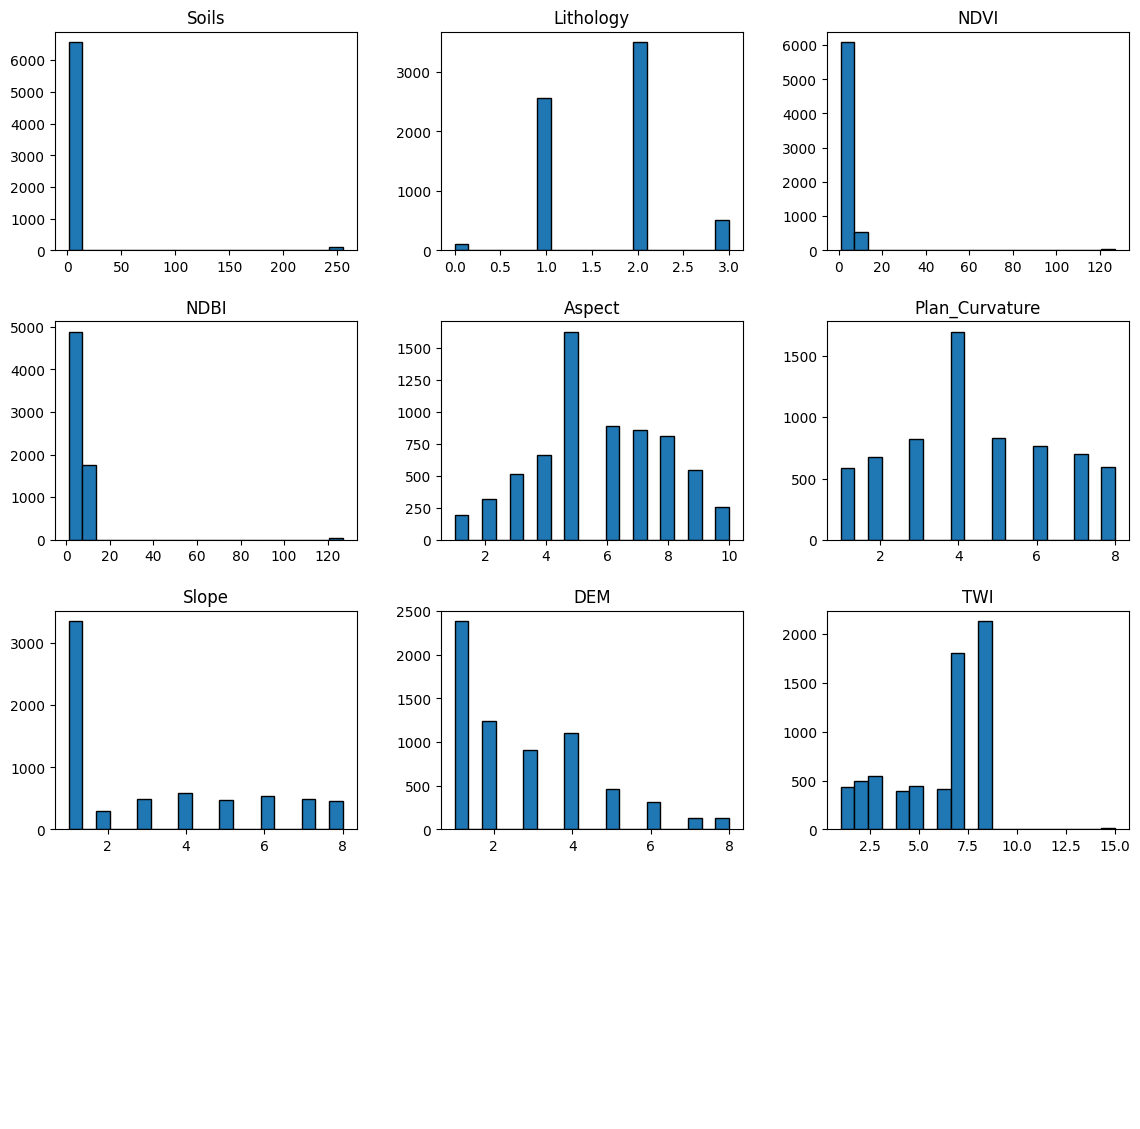

In [ ]:
# Importando biblioteca
import matplotlib.pyplot as plt

# Criando subplots
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
fig.tight_layout(pad=3.0)

# Configurações do histograma
hist_kwargs = {'bins': 20, 'edgecolor': 'black'}

# Plotando histogramas
axes[0, 0].hist(bd_aprendizagem_ini['Soils'], **hist_kwargs)
axes[0, 0].set_title('Soils')

axes[0, 1].hist(bd_aprendizagem_ini['Lithology'], **hist_kwargs)
axes[0, 1].set_title('Lithology')

axes[0, 2].hist(bd_aprendizagem_ini['NDVI'], **hist_kwargs)
axes[0, 2].set_title('NDVI')

axes[1, 0].hist(bd_aprendizagem_ini['NDBI'], **hist_kwargs)
axes[1, 0].set_title('NDBI')

axes[1, 1].hist(bd_aprendizagem_ini['Aspect'], **hist_kwargs)
axes[1, 1].set_title('Aspect')

axes[1, 2].hist(bd_aprendizagem_ini['Plan_Curvature'], **hist_kwargs)
axes[1, 2].set_title('Plan_Curvature')

axes[2, 0].hist(bd_aprendizagem_ini['Slope'], **hist_kwargs)
axes[2, 0].set_title('Slope')

axes[2, 1].hist(bd_aprendizagem_ini['DEM'], **hist_kwargs)
axes[2, 1].set_title('DEM')

axes[2, 2].hist(bd_aprendizagem_ini['TWI'], **hist_kwargs)
axes[2, 2].set_title('TWI')

# Desabilitando o último subplot vazio
axes[3, 0].axis('off')
axes[3, 1].axis('off')
axes[3, 2].axis('off')

# Exibindo o gráfico
plt.show()


/tmp/ipython-input-239133099.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=bd_aprendizagem_ini, color='random')


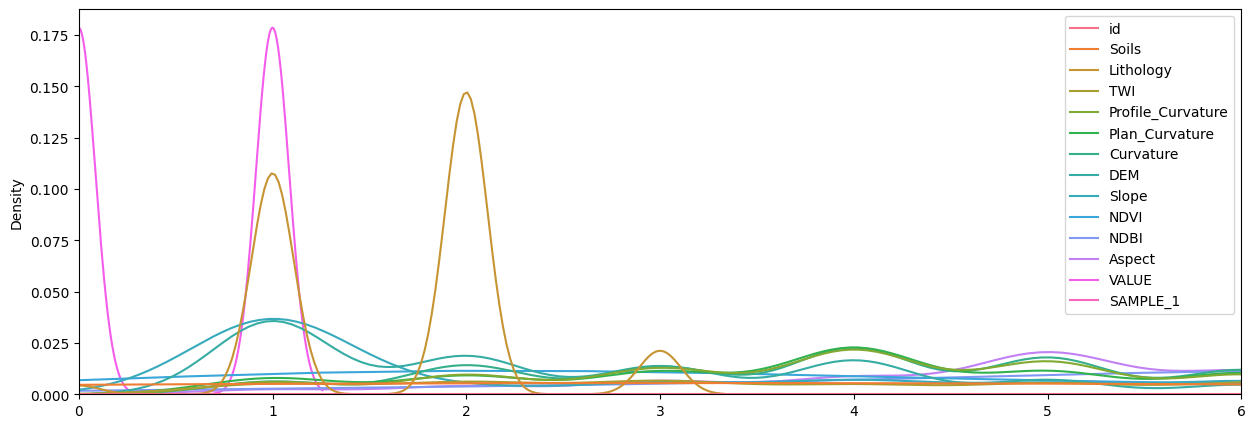

In [ ]:
#plotando a distribuição de frequência
import seaborn as sns
# Definir as dimensões da figura
largura = 15
altura = 5

# Plotar o histograma com dimensões maiores
plt.figure(figsize=(largura, altura))
sns.kdeplot(data=bd_aprendizagem_ini, color='random')

#sns.kdeplot(data=bd_aprendizagem_ini['occ'], fill=True, color='black')  # Adicionado fill=True para preencher a área sob a curva

# Ajustar os limites do eixo x
plt.xlim(0, 6)

# Exibir o histograma
plt.show()

# **ANÁLISE DE PESOS**

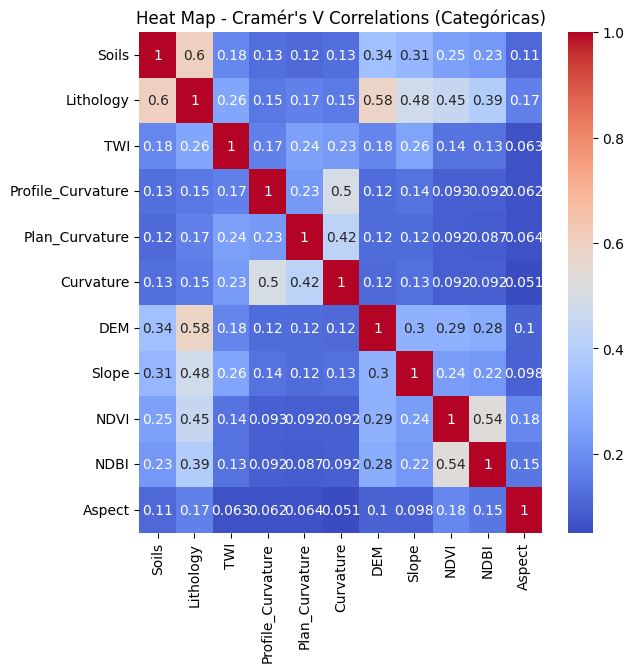

In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from shapely.geometry import Point
from shapely.ops import unary_union
import os

# Função para calcular o Coeficiente de Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    return np.sqrt(chi2 / (len(x) * (min(confusion_matrix.shape) - 1)))

# Supondo que `df_corr` seja o DataFrame com as variáveis categóricas
df_corr = points_FC_norm_clean.iloc[:, 2:13]  # Excluindo as informações geográficas

# Criando uma matriz para armazenar o Coeficiente de Cramér's V
cramers_v_matrix = pd.DataFrame(index=df_corr.columns, columns=df_corr.columns)

# Calculando o Coeficiente de Cramér's V para cada par de colunas
for col1 in df_corr.columns:
    for col2 in df_corr.columns:
        if col1 != col2:
            cramers_v_matrix.loc[col1, col2] = cramers_v(df_corr[col1], df_corr[col2])
        else:
            cramers_v_matrix.loc[col1, col2] = 1.0  # Correlação perfeita consigo mesmo

# Convertendo a matriz para float (para garantir que o heatmap funcione corretamente)
cramers_v_matrix = cramers_v_matrix.astype(float)

# 1. Mapa de calor do Coeficiente de Cramér's V
plt.figure(figsize=(6.5, 6.5))
sns.heatmap(cramers_v_matrix, annot=True, cmap="coolwarm", xticklabels=cramers_v_matrix.columns, yticklabels=cramers_v_matrix.columns)
plt.title('Heat Map - Cramér\'s V Correlations (Categóricas)')
plt.show()

# 2. Filtrando valores de Cramér's V maiores que 0.5 e menores que -0.5
# Como Cramér's V é sempre positivo, vamos filtrar apenas valores maiores que 0.5
high_cramers_v = cramers_v_matrix[cramers_v_matrix > 0.5].dropna(axis=0, how='all').dropna(axis=1, how='all')

In [ ]:
points_FC_norm_clean.head()

,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,NDVI,NDBI,Aspect
0,1102,POINT (568467.877 7455760.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,6.0000,5.0000,5.0000
1,1103,POINT (568467.877 7455755.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,6.0000,5.0000,5.0000
2,1104,POINT (568467.877 7455750.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,6.0000,5.0000,5.0000
3,1105,POINT (568467.877 7455745.944),7.0000,3.0000,2.0000,1.0000,7.0000,8.0000,8.0000,4.0000,6.0000,5.0000,6.0000
4,1106,POINT (568467.877 7455740.944),7.0000,3.0000,2.0000,1.0000,7.0000,8.0000,8.0000,4.0000,6.0000,5.0000,6.0000


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 4.1 MB/s eta 0:00:00
Explained variance by components (inertia): [0.25269901 0.13697472 0.11687012 0.09706162 0.09331421 0.08433684
 0.08009544 0.07147881 0.06716922]


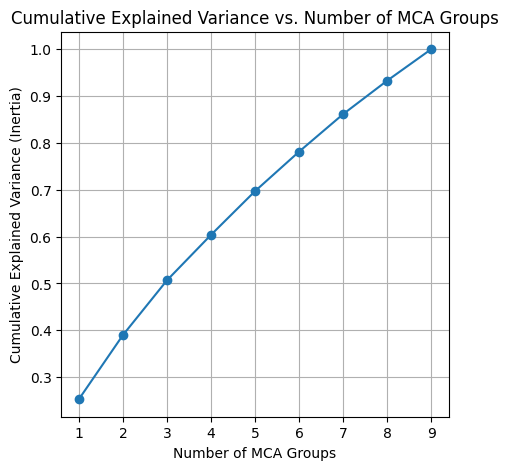

In [ ]:
!pip install prince
import prince
import numpy as np
import matplotlib.pyplot as plt

# 1. Select categorical variables (appropriate columns of your DataFrame)
df_corr = points_FC_norm_clean.iloc[:, 2:13]  # Adjust as needed

# 2. Applying MCA (Multiple Correspondence Analysis)
# The number of components can be adjusted based on your needs
mca = prince.MCA(n_components=9, n_iter=3, copy=True, check_input=True)
mca = mca.fit(df_corr)  # Fit MCA to the data

# 3. Explained variance: For MCA, explained variance can be calculated using the eigenvalues (singular values).
# MCA calculates the "inertia" total, and the variance explained by each component can be derived from the contribution of each component.

# Eigenvalues (contribution of each component)
eigenvalues = mca.eigenvalues_

# Explained variance per component: each eigenvalue / sum of eigenvalues
explained_inertia = eigenvalues / eigenvalues.sum()

# Print the explained variance for each component
print(f"Explained variance by components (inertia): {explained_inertia}")

# Cumulative explained variance plot
explained_inertia_cumsum = np.cumsum(explained_inertia)

x = np.arange(1, len(explained_inertia_cumsum) + 1)

# Resize the figure to 10 in width and 6 in height
plt.figure(figsize=(5, 5))  # <- Here you define the figure size

plt.plot(x, explained_inertia_cumsum, marker='o', linestyle='-')
plt.xlabel("Number of MCA Groups")
plt.ylabel("Cumulative Explained Variance (Inertia)")
plt.title("Cumulative Explained Variance vs. Number of MCA Groups")
plt.grid(True)
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index(['id', 'geometry', 'Soils', 'Lithology', 'TWI', 'Profile_Curvature',
       'Plan_Curvature', 'Curvature', 'DEM', 'Slope', 'NDVI', 'NDBI', 'Aspect',
       'MCA1', 'MCA2', 'MCA3', 'MCA4', 'MCA5', 'MCA6', 'MCA7', 'MCA8'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

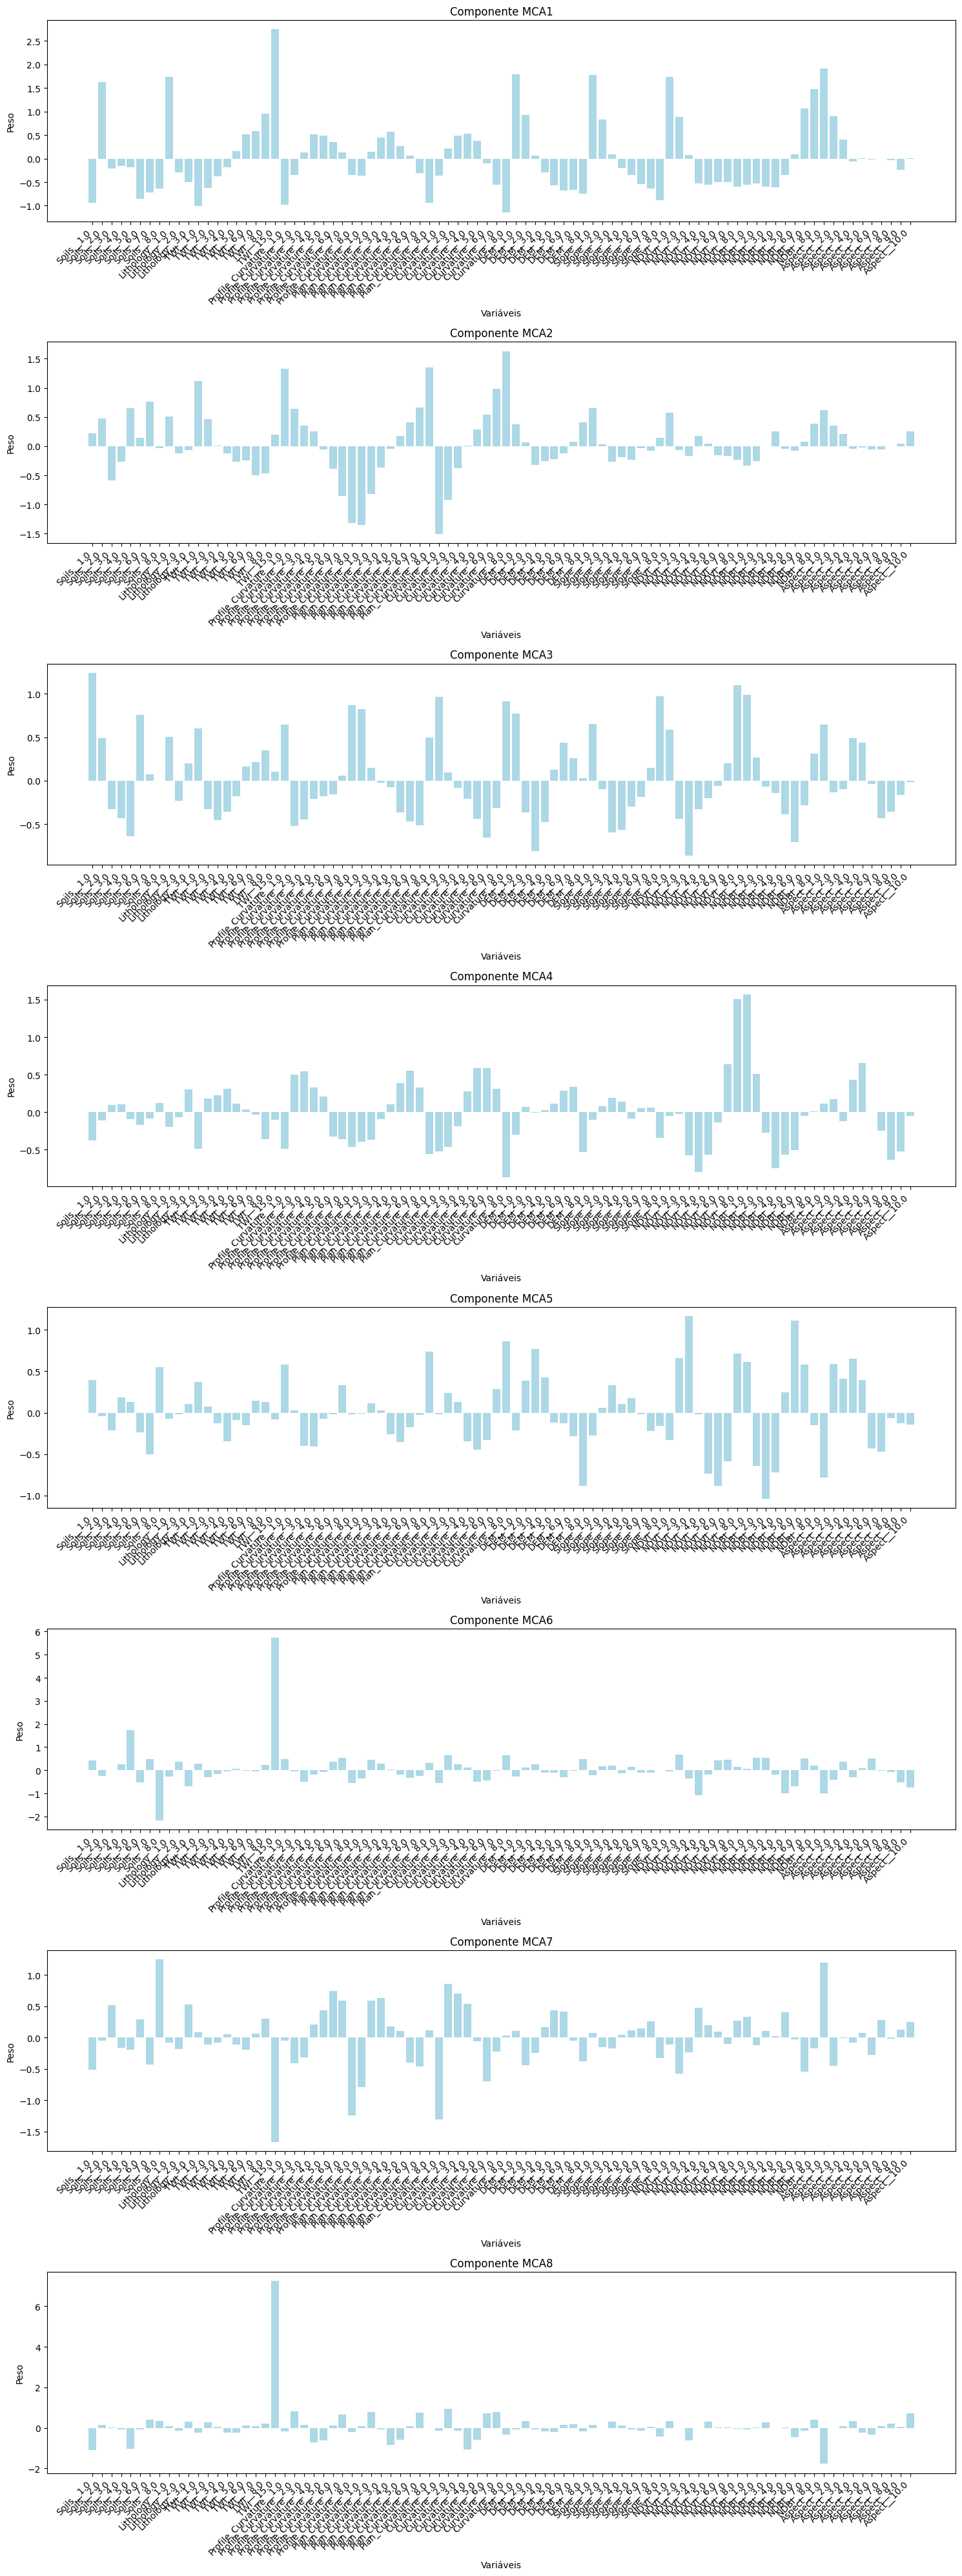

In [ ]:
# 4. Transformando os dados para o novo espaço dimensional reduzido (8 componentes)
transformed_data = mca.transform(df_corr)

# Verifique o tipo de transformed_data
print(type(transformed_data))  # Verifique se é um numpy array ou DataFrame

# Se for um DataFrame, extraímos as componentes principais e adicionamos ao DataFrame original
if isinstance(transformed_data, pd.DataFrame):
    for i in range(8):
        points_FC_norm_clean[f'MCA{i+1}'] = transformed_data.iloc[:, i]  # Usamos iloc para acessar as colunas

# Caso seja um numpy array, use o código abaixo:
if isinstance(transformed_data, np.ndarray):
    for i in range(8):
        points_FC_norm_clean[f'MCA{i+1}'] = transformed_data[:, i]  # Acesso correto a um array numpy

# Exibindo as colunas do DataFrame com as novas variáveis MCA
print(points_FC_norm_clean.columns)

# Obtendo as coordenadas das variáveis (cargas)
coordinates = mca.column_coordinates(df_corr)

# Agora vamos plotar os pesos de cada variável em cada componente MCA
# O dataframe 'coordinates' contém as contribuições de cada variável para os componentes

# Alargando o eixo X e organizando os subplots em uma coluna
plt.figure(figsize=(15, 40))  # Ajuste do tamanho da figura para dar mais espaço vertical

for i in range(8):  # Limitando para 8 componentes
    plt.subplot(8, 1, i+1)  # Subplots em uma única coluna
    plt.bar(coordinates.index, coordinates.iloc[:, i], color='lightblue')
    plt.title(f'Componente MCA{i+1}')
    plt.xlabel('Variáveis')
    plt.ylabel('Peso')
    plt.xticks(rotation=45, ha='right')  # Girando os rótulos e ajustando para ficarem legíveis

plt.tight_layout()  # Ajusta os espaços entre os gráficos
plt.show()

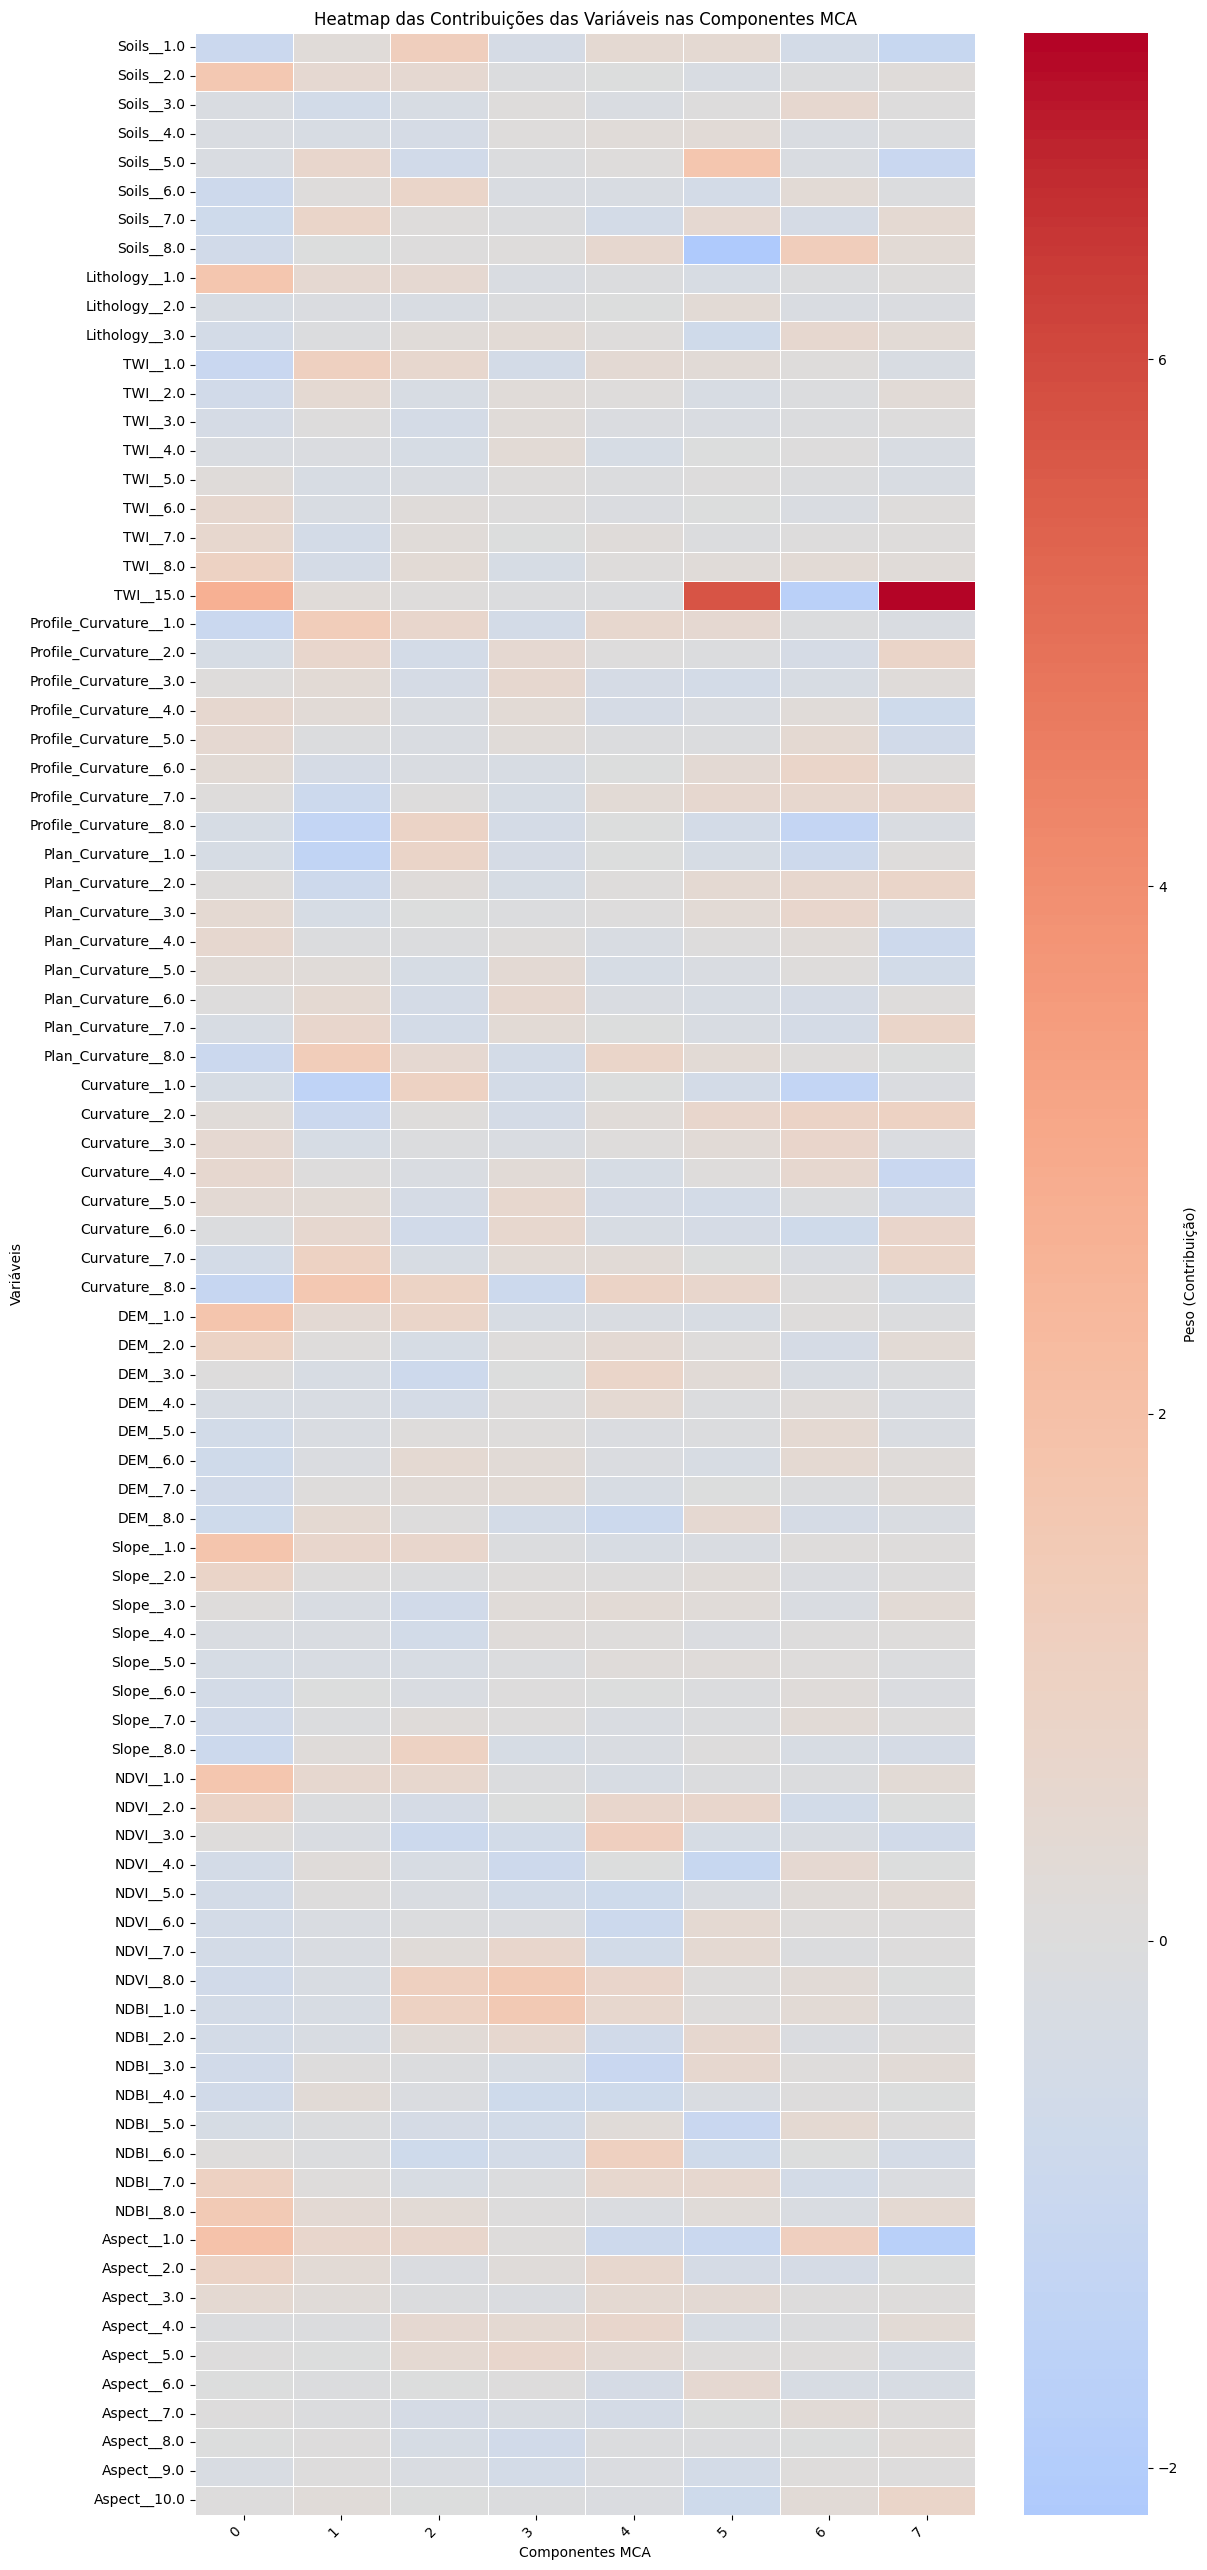

Heatmap para as contribuições das variáveis em 8 componentes gerado.


/tmp/ipython-input-1567790519.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = plot_data.applymap(lambda x: -3 < x < 3)


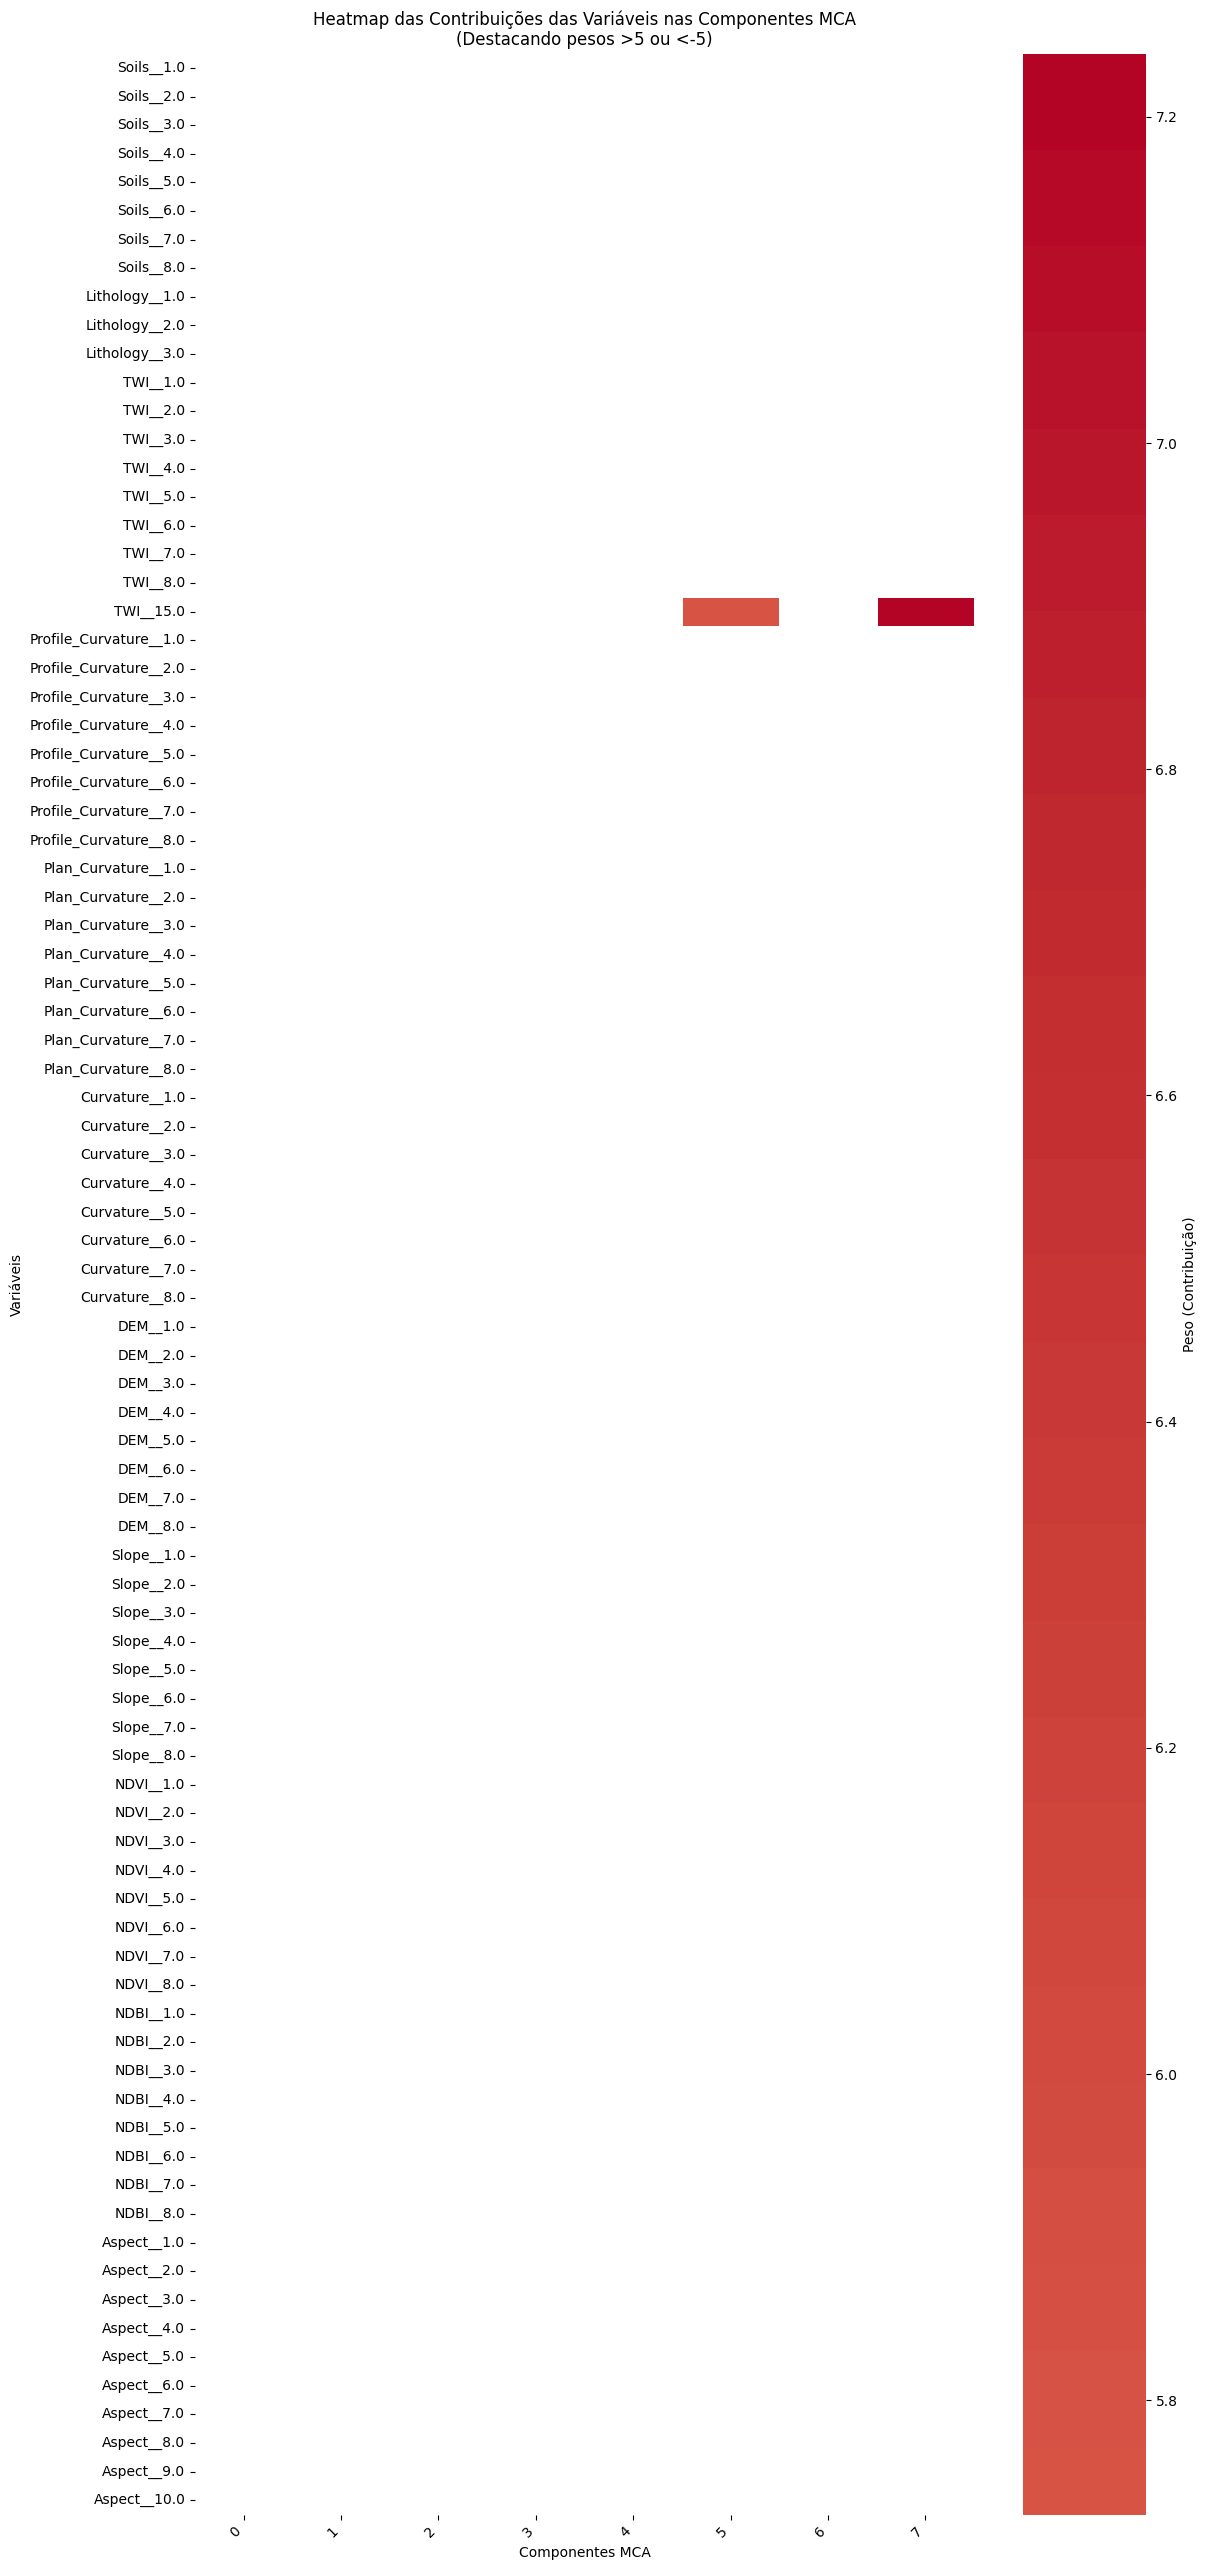

Heatmap com destaques apenas para valores >5 ou <-5 gerado.


In [ ]:
df_coords = coordinates # << Substitua aqui, se necessário

# Número de componentes a incluir no heatmap (ex: 8 para MCA1 a MCA8)
n_components = 8 # << Ajuste conforme necessário

# Seleciona as colunas das componentes desejadas
component_columns = list(range(n_components))  # [0, 1, 2, ..., 7]
plot_data = df_coords[component_columns]

# Tamanho da figura (ajuste para melhor visualização)
# A largura depende do número de componentes, a altura do número de variáveis
fig_width = max(12, n_components * 1.2) # Largura mínima de 12, aumenta com componentes
fig_height = max(15, len(df_coords.index) * 0.3) # Altura mínima de 15, aumenta com variáveis

# --- Geração do Heatmap ---

plt.figure(figsize=(fig_width, fig_height))

# Cria o heatmap usando seaborn
# - annot=False: Não mostra os valores numéricos nas células (pode ficar poluído)
#   Se tiver poucas variáveis, pode definir como True.
# - cmap='coolwarm': Um mapa de cores divergente (bom para valores positivos/negativos)
#   Outras opções: 'RdBu_r', 'viridis', 'plasma'
# - center=0: Centraliza a escala de cores em zero
sns.heatmap(plot_data, annot=False, cmap='coolwarm', center=0, linewidths=.5, cbar_kws={'label': 'Peso (Contribuição)'})

plt.title('Heatmap das Contribuições das Variáveis nas Componentes MCA')
plt.xlabel('Componentes MCA')
plt.ylabel('Variáveis')
plt.xticks(rotation=45, ha='right') # Rotaciona rótulos do eixo X se necessário
plt.yticks(rotation=0) # Mantém rótulos do eixo Y horizontais

plt.tight_layout() # Ajusta o espaçamento
plt.show()

print(f"Heatmap para as contribuições das variáveis em {n_components} componentes gerado.")
# Máscara booleana: True onde os valores estão ENTRE -5 e 5 (valores que queremos "apagar")
mask = plot_data.applymap(lambda x: -3 < x < 3)

plt.figure(figsize=(fig_width, fig_height))

# Gera o heatmap com a máscara
sns.heatmap(
    plot_data,
    mask=mask,  # Aplica a máscara
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Peso (Contribuição)'}
)

plt.title('Heatmap das Contribuições das Variáveis nas Componentes MCA\n(Destacando pesos >5 ou <-5)')
plt.xlabel('Componentes MCA')
plt.ylabel('Variáveis')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print(f"Heatmap com destaques apenas para valores >5 ou <-5 gerado.")


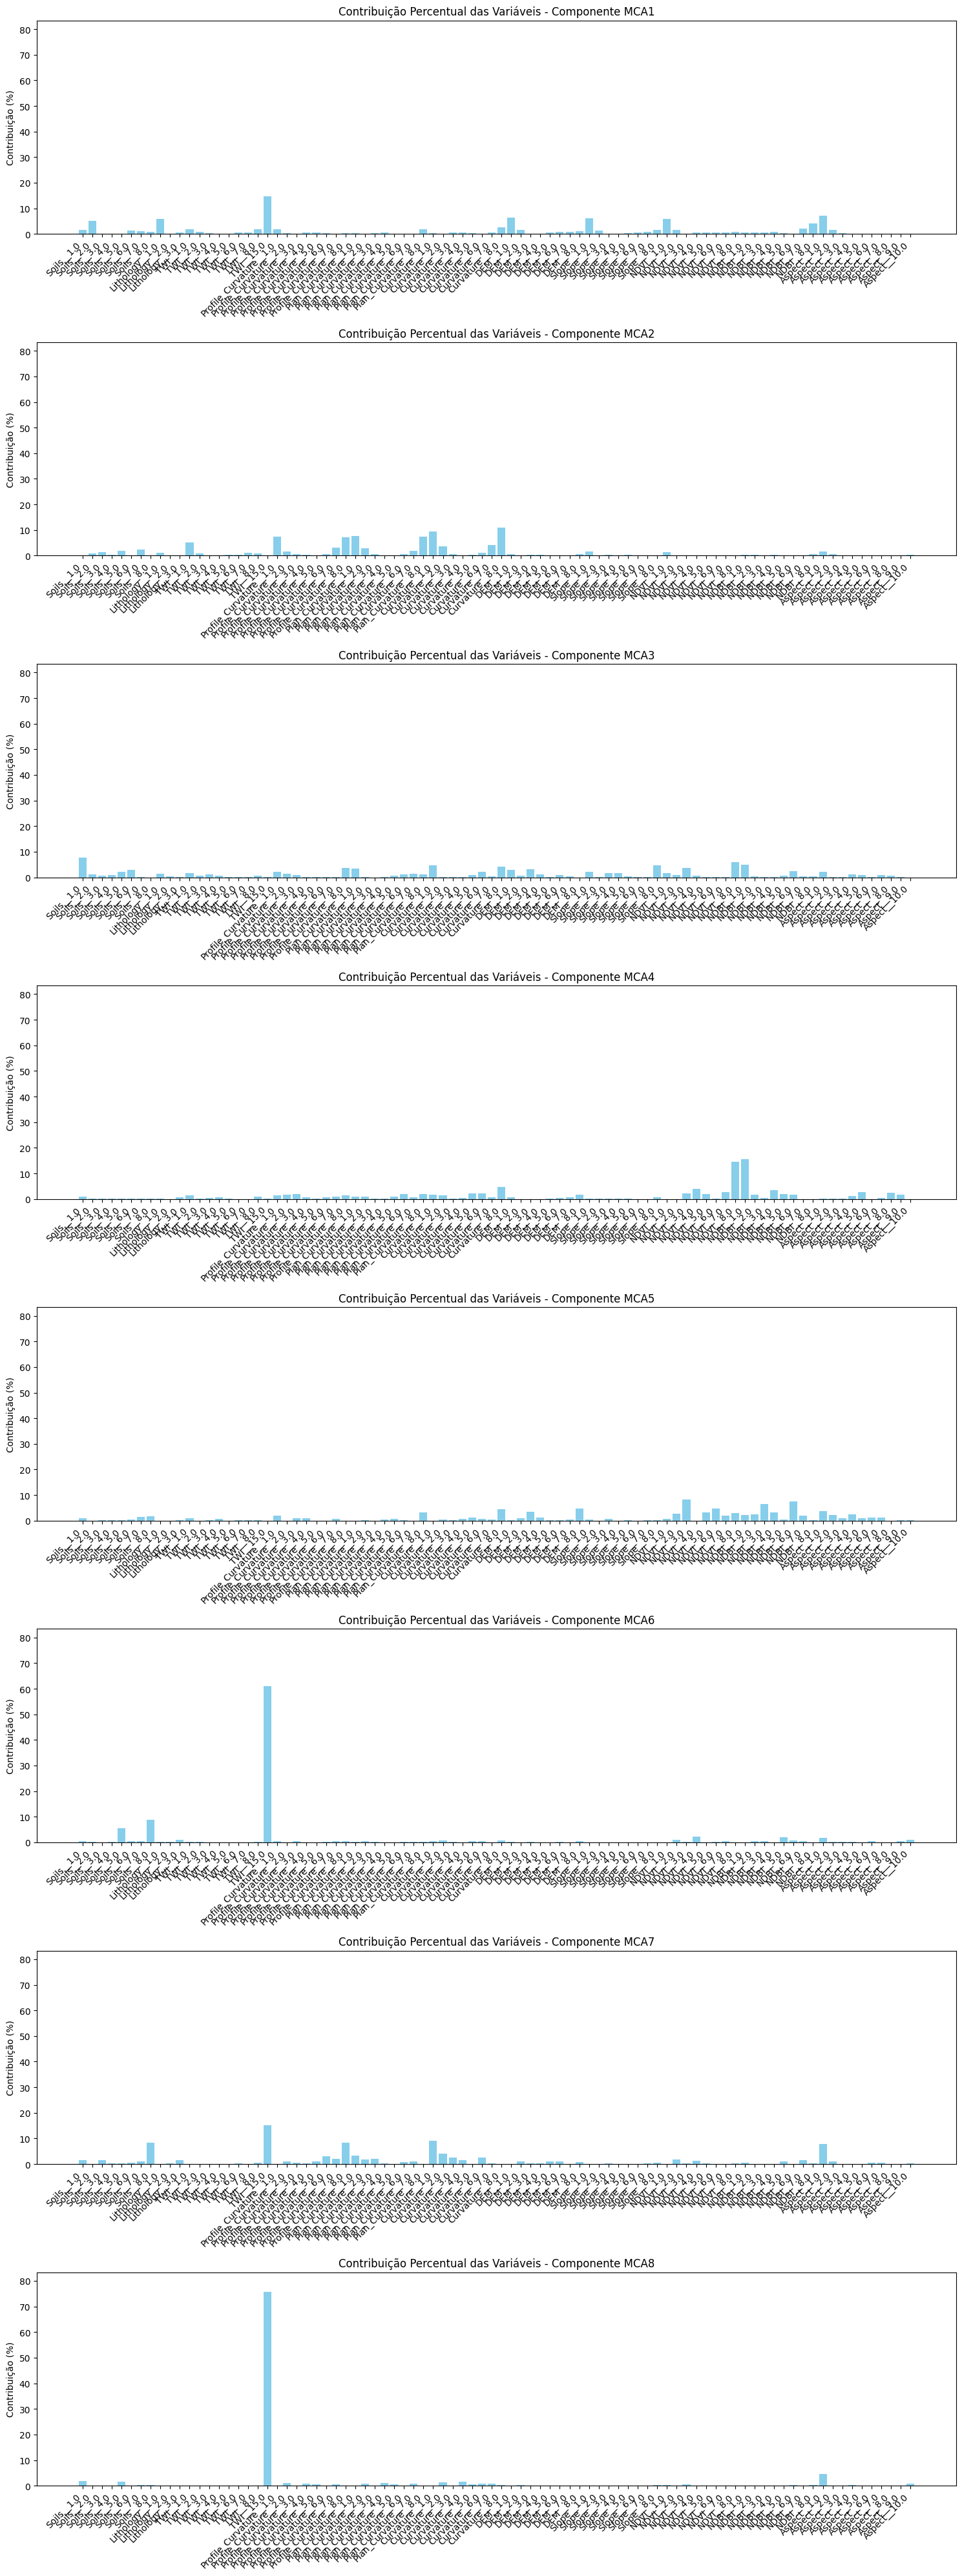

In [ ]:
# 1. Obter as coordenadas das variáveis (cargas fatoriais)
coordinates = mca.column_coordinates(df_corr)

# 2. Calcular a soma dos quadrados das coordenadas por componente
#    (isso equivale à "variância explicada" por variável em cada componente)
squared = coordinates ** 2

# 3. Converter para contribuição percentual (cada valor dividido pela soma da coluna)
contributions = squared.div(squared.sum(axis=0), axis=1) * 100

# 4. Selecionar os primeiros 8 componentes
n_components = 8
contributions = contributions.iloc[:, :n_components]

# 5. Plotar os gráficos: um por componente
plt.figure(figsize=(15, 40))

for i in range(n_components):
    plt.subplot(n_components, 1, i+1)
    plt.bar(contributions.index, contributions.iloc[:, i], color='skyblue')
    plt.title(f'Contribuição Percentual das Variáveis - Componente MCA{i+1}')
    plt.ylabel('Contribuição (%)')
    plt.ylim(0, contributions.values.max() * 1.1)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

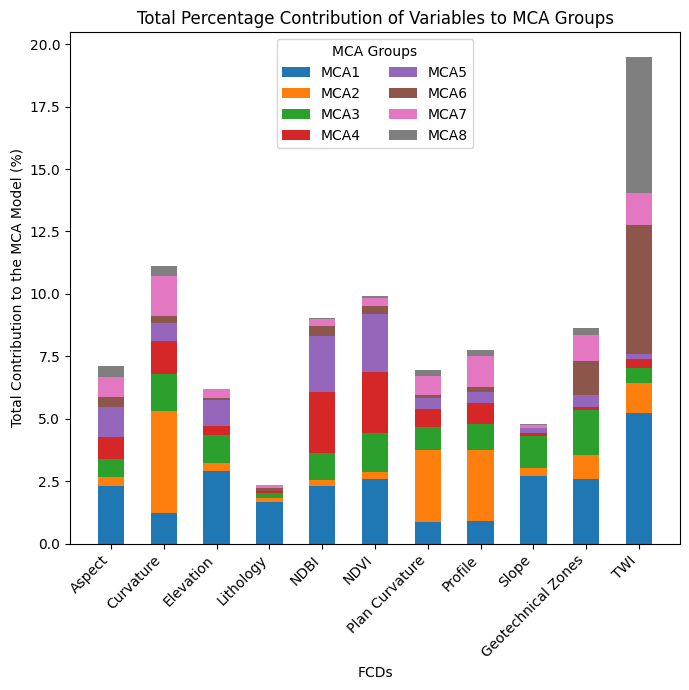

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Obter as coordenadas principais das colunas (variáveis categóricas)
coords = mca.column_coordinates(df_corr)

# 2. Elevar ao quadrado (coordenadas principais ao quadrado = importância bruta por classe e componente)
squared = coords ** 2

# 3. Calcular contribuição relativa de cada classe em cada componente (normalizando por componente)
contrib = squared.div(squared.sum(axis=0), axis=1)

# 4. Obter inércia (variância explicada) de cada componente
eigvals = mca.eigenvalues_
inertia = eigvals / eigvals.sum()

# 5. Ponderar as contribuições de cada classe pela inércia dos componentes
weighted_contrib = contrib * inertia

# 6. Agrupar por variável (usa o prefixo antes do "_")
variable_names = coords.index.to_series().str.extract(r'(^[^_]+)')[0]
grouped = weighted_contrib.groupby(variable_names).sum()

# 7. Converter para percentual
grouped_percent = grouped * 100
grouped_percent = grouped_percent.iloc[:, :8]

# 7b. Rename index for readable names in the plot (English)
nomes_legiveis = {
    'DEM': 'Elevation',
    'Lithology': 'Lithology',
    'NDBI': 'NDBI',
    'NDVI': 'NDVI',
    'Plan': 'Plan Curvature',
    'Slope': 'Slope',
    'Soils': 'Geotechnical Zones',
    'TWI': 'TWI',
    'Aspect': 'Aspect'
}

grouped_percent.rename(index=nomes_legiveis, inplace=True)

# 8. Plotar gráfico de barras empilhadas com barras mais finas
plt.figure(figsize=(7, 7))
colors = plt.cm.tab10.colors

# Definir a posição das barras, garantindo que fiquem mais próximas
x_pos = np.arange(len(grouped_percent))  # Posições no eixo X
bar_width = 0.5  # Largura das barras

# Configurar o deslocamento entre as barras para controlar o espaçamento
spacing = 0  # Ajuste esse valor para controlar o espaçamento (0.15 é um bom valor para começar)

# Inicializa o acumulador para o fundo das barras empilhadas
bottom = np.zeros(len(grouped_percent))

# Itera sobre cada componente e empilha as barras
for i in range(grouped_percent.shape[1]):
    plt.bar(
        x_pos + i * spacing,  # Ajuste a posição das barras com base no índice e no espaçamento
        grouped_percent.iloc[:, i],
        bottom=bottom,
        label=f'MCA{i+1}',
        color=colors[i % len(colors)],
        width=bar_width,  # Largura controlada
        align='center'  # Alinha ao centro
    )
    bottom += grouped_percent.iloc[:, i]  # Atualiza a base para o próximo componente

# Chart settings
plt.ylabel('Total Contribution to the MCA Model (%)')
plt.xlabel('FCDs')
plt.title('Total Percentage Contribution of Variables to MCA Groups')

# Ajustar rótulos do eixo X
plt.xticks(x_pos, grouped_percent.index, rotation=45, ha='right')

plt.legend(title='MCA Groups', ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1))

# Ajuste para o layout
plt.savefig('MCA CONTRIBUTIONS.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()




In [ ]:
print(grouped_percent.columns)


RangeIndex(start=0, stop=8, step=1)


In [ ]:
bd_aprendizagem_ini.head()

,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,NDVI,NDBI,Aspect,VALUE,SAMPLE_1
0,100100.0000,POINT (569097.877 7455320.944),4,3,1,1,8,8,6,8,8,1,5,1,NaN
1,100101.0000,POINT (569097.877 7455315.944),4,3,1,1,8,8,6,8,8,1,5,1,NaN
2,100885.0000,POINT (569102.877 7455320.944),4,3,1,1,8,8,6,8,8,1,5,1,NaN
3,100886.0000,POINT (569102.877 7455315.944),4,3,1,1,8,8,6,8,8,1,5,1,NaN
4,100887.0000,POINT (569102.877 7455310.944),4,3,1,1,8,8,6,8,8,1,5,1,NaN


In [ ]:
points_FC_norm_clean.head()

,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,...,NDBI,Aspect,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8
0,1102,POINT (568467.877 7455760.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,...,5.0000,5.0000,0.0978,0.2199,0.0046,0.2341,-0.4613,-0.9095,0.4940,-0.3501
1,1103,POINT (568467.877 7455755.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,...,5.0000,5.0000,0.0978,0.2199,0.0046,0.2341,-0.4613,-0.9095,0.4940,-0.3501
2,1104,POINT (568467.877 7455750.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,...,5.0000,5.0000,0.0978,0.2199,0.0046,0.2341,-0.4613,-0.9095,0.4940,-0.3501
3,1105,POINT (568467.877 7455745.944),7.0000,3.0000,2.0000,1.0000,7.0000,8.0000,8.0000,4.0000,...,5.0000,6.0000,-0.8085,0.8581,-0.0070,-0.3667,-0.1670,0.1557,-0.1471,0.2136
4,1106,POINT (568467.877 7455740.944),7.0000,3.0000,2.0000,1.0000,7.0000,8.0000,8.0000,4.0000,...,5.0000,6.0000,-0.8085,0.8581,-0.0070,-0.3667,-0.1670,0.1557,-0.1471,0.2136


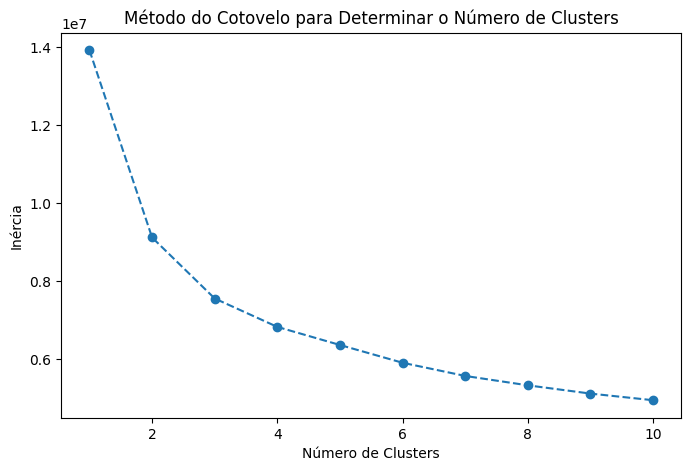

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


                         geometry  cluster
0  POINT (568467.877 7455760.944)        3
1  POINT (568467.877 7455755.944)        3
2  POINT (568467.877 7455750.944)        3
3  POINT (568467.877 7455745.944)        1
4  POINT (568467.877 7455740.944)        1


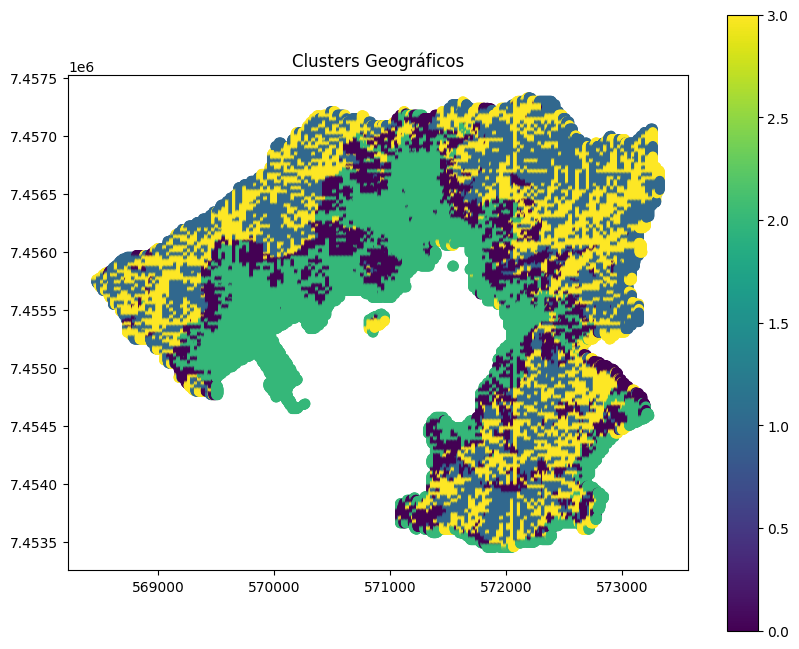

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Selecionar as colunas de interesse para a clusterização
predictor_columns = ['DEM',	'NDVI',	'Slope',	'Aspect',	'NDBI',	'Lithology',	'Soils',	'Plan_Curvature',	'TWI']

# Extrair os dados das colunas selecionadas
X = points_FC_norm_clean[predictor_columns].values

# Determinar o número ideal de clusters usando o método do cotovelo
inertia = []
range_n_clusters = range(1, 11)  # Testar de 1 a 10 clusters
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plotar o gráfico do método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Determinar o Número de Clusters')
plt.show()

# Escolher o número ideal de clusters com base no gráfico
optimal_clusters = 4  # Substitua pelo número ideal identificado no gráfico

# Aplicar o K-Means com o número ideal de clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
points_FC_norm_clean['cluster'] = kmeans.fit_predict(X)

# Exibir os primeiros registros com os clusters atribuídos
print(points_FC_norm_clean[['geometry', 'cluster']].head())

# Opcional: plotar os clusters no mapa
points_FC_norm_clean.plot(column='cluster', cmap='viridis', legend=True, figsize=(10, 8))
plt.title('Clusters Geográficos')
plt.show()


In [ ]:
 bd_aprendizagem_ini.VALUE.value_counts()

,count
VALUE,
1,3339
0,3339


In [ ]:
# Realize um merge com base na coluna 'geometry'
merged = bd_aprendizagem_ini.merge(
    points_FC_norm_clean[['geometry', 'MCA1', 'MCA2', 'MCA3', 'MCA4', 'MCA5', 'MCA6', 'MCA7', 'MCA8', 'cluster']],
    on='geometry',
    how='left'
)

# Verifique o resultado
merged = merged.dropna(subset=['geometry', 'MCA1', 'MCA2', 'MCA3', 'MCA4', 'MCA5', 'MCA6', 'MCA7', 'MCA8', 'cluster'])

# Selecionar apenas colunas numéricas, excluindo a coluna geométrica
numeric_columns = merged.select_dtypes(include=['number'])

# Mostrar o mínimo e máximo de todas as colunas numéricas
print("Mínimos:")
print(numeric_columns.min())

print("\nMáximos:")
print(numeric_columns.max())

Mínimos:
id                  100100.0000
Soils                    1.0000
Lithology                1.0000
TWI                      1.0000
Profile_Curvature        1.0000
Plan_Curvature           1.0000
Curvature                1.0000
DEM                      1.0000
Slope                    1.0000
NDVI                     1.0000
NDBI                     1.0000
Aspect                   1.0000
VALUE                    0.0000
SAMPLE_1                 1.0000
MCA1                    -1.0567
MCA2                    -1.0942
MCA3                    -1.0983
MCA4                    -1.0882
MCA5                    -0.8721
MCA6                    -1.0924
MCA7                    -1.1911
MCA8                    -1.3027
cluster                  0.0000
dtype: float64

Máximos:
id                  763967.0000
Soils                    7.0000
Lithology                3.0000
TWI                     15.0000
Profile_Curvature        8.0000
Plan_Curvature           8.0000
Curvature                8.0000
DEM   

In [ ]:
print(merged.shape)
merged.VALUE.value_counts()

(6570, 24)


,count
VALUE,
1,3339
0,3231


In [ ]:
import rasterio as rio
import numpy as np
import geopandas as gpd

# Caminho do arquivo raster (inventário)
inv = '/content/drive/MyDrive/dados tese/inventario_tese/cicatrizes_2010_2021_ufrj_uff.tif'

# Carregar o GeoDataFrame de pontos (substitua pelo caminho e leitura do seu arquivo)
# points_FC_norm_clean = gpd.read_file('caminho_do_seu_geodataframe.shp')

# Verificação do CRS e extração dos valores do raster
values = []

with rio.open(inv) as dataset:
    raster_data = dataset.read(1)  # Ler os dados do raster como uma matriz numpy
    raster_crs = dataset.crs       # Obter o sistema de referência do raster

    # Verificar se o CRS dos pontos é o mesmo do raster
    if points_FC_norm_clean.crs != raster_crs:
        points_FC_norm_clean = points_FC_norm_clean.to_crs(raster_crs)

    # Iterar sobre os pontos do GeoDataFrame
    for point in points_FC_norm_clean['geometry']:
        x, y = point.x, point.y  # Coordenadas do ponto
        try:
            # Converter as coordenadas para índices do raster
            row, col = dataset.index(x, y)

            # Obter o valor do raster no índice correspondente
            value = raster_data[row, col]
        except IndexError:
            # Atribuir NaN se o ponto estiver fora do raster
            value = np.nan

        # Adicionar o valor à lista
        values.append(value)

# Adicionar os valores extraídos como uma coluna no GeoDataFrame
points_FC_norm_clean['occ'] = values

# Exibir os primeiros registros para validação
points_FC_norm_clean

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,...,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,cluster,occ
0,1102,POINT (568467.877 7455760.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,...,0.0978,0.2199,0.0046,0.2341,-0.4613,-0.9095,0.4940,-0.3501,3,0.0000
1,1103,POINT (568467.877 7455755.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,...,0.0978,0.2199,0.0046,0.2341,-0.4613,-0.9095,0.4940,-0.3501,3,0.0000
2,1104,POINT (568467.877 7455750.944),8.0000,3.0000,6.0000,4.0000,5.0000,5.0000,8.0000,1.0000,...,0.0978,0.2199,0.0046,0.2341,-0.4613,-0.9095,0.4940,-0.3501,3,0.0000
3,1105,POINT (568467.877 7455745.944),7.0000,3.0000,2.0000,1.0000,7.0000,8.0000,8.0000,4.0000,...,-0.8085,0.8581,-0.0070,-0.3667,-0.1670,0.1557,-0.1471,0.2136,1,0.0000
4,1106,POINT (568467.877 7455740.944),7.0000,3.0000,2.0000,1.0000,7.0000,8.0000,8.0000,4.0000,...,-0.8085,0.8581,-0.0070,-0.3667,-0.1670,0.1557,-0.1471,0.2136,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376438,763964,POINT (573327.877 7456550.944),7.0000,2.0000,2.0000,1.0000,8.0000,8.0000,8.0000,4.0000,...,-0.9019,1.0871,0.0248,-0.8716,-0.0578,0.2394,-0.0481,-0.0080,1,1.0000
376439,763965,POINT (573327.877 7456545.944),7.0000,2.0000,2.0000,1.0000,8.0000,8.0000,8.0000,4.0000,...,-0.9019,1.0871,0.0248,-0.8716,-0.0578,0.2394,-0.0481,-0.0080,1,1.0000
376440,763966,POINT (573327.877 7456540.944),7.0000,2.0000,2.0000,1.0000,8.0000,8.0000,8.0000,4.0000,...,-0.9019,1.0871,0.0248,-0.8716,-0.0578,0.2394,-0.0481,-0.0080,1,1.0000
376441,763967,POINT (573327.877 7456535.944),7.0000,2.0000,2.0000,1.0000,8.0000,8.0000,8.0000,4.0000,...,-0.8983,1.0266,0.0772,-0.7289,-0.2471,0.5886,-0.1380,-0.0000,1,1.0000


In [ ]:
points_FC_norm_clean['occ'].value_counts()

,count
occ,
0.0000,364681
1.0000,3344


In [ ]:
from sklearn.utils import resample

# Separando as classes majoritária e minoritária
majority_class = points_FC_norm_clean[points_FC_norm_clean['occ'] == 0.0]
minority_class = points_FC_norm_clean[points_FC_norm_clean['occ'] == 1.0]

# Realizando o downsampling na classe majoritária
majority_downsampled = resample(majority_class,
                                replace=False,                  # Sem reposição
                                n_samples=len(minority_class),  # Igualando ao tamanho da classe minoritária
                                random_state=42)

# Combinando ambas as classes
points_FC_downsampled = pd.concat([majority_downsampled, minority_class])

# Verificando a nova distribuição
print(points_FC_downsampled['occ'].value_counts())

# Embaralhando os dados
points_FC_downsampled = points_FC_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

occ
0.0000    3344
1.0000    3344
Name: count, dtype: int64


In [ ]:
print(points_FC_downsampled.head())
points_FC_downsampled['cluster'].value_counts()
points_FC_downsampled['occ'].value_counts()

       id                        geometry  Soils  Lithology    TWI  \
0  457146  POINT (571372.877 7455965.944) 2.0000     1.0000 4.0000   
1  247713  POINT (570037.877 7455155.944) 2.0000     1.0000 7.0000   
2  615007  POINT (572377.877 7455585.944) 4.0000     2.0000 2.0000   
3  612449  POINT (572362.877 7456600.944) 1.0000     2.0000 1.0000   
4  631553  POINT (572482.877 7455280.944) 4.0000     2.0000 5.0000   

   Profile_Curvature  Plan_Curvature  Curvature    DEM  Slope  ...    MCA1  \
0             6.0000          7.0000     5.0000 1.0000 2.0000  ...  0.8424   
1             7.0000          4.0000     3.0000 1.0000 1.0000  ...  1.5242   
2             1.0000          6.0000     7.0000 3.0000 5.0000  ... -0.5324   
3             1.0000          2.0000     8.0000 8.0000 8.0000  ... -0.9361   
4             6.0000          6.0000     4.0000 4.0000 2.0000  ...  0.0423   

     MCA2    MCA3    MCA4    MCA5    MCA6    MCA7    MCA8  cluster    occ  
0  0.2794 -0.1704 -0.0568  0.3969 

,count
occ,
0.0000,3344
1.0000,3344


# **ANÁLISE CLASSIFICATÓRIA**

In [ ]:
merged.head()

,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,...,SAMPLE_1,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,cluster
0,100100.0000,POINT (569097.877 7455320.944),4,3,1,1,8,8,6,8,...,NaN,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
1,100101.0000,POINT (569097.877 7455315.944),4,3,1,1,8,8,6,8,...,NaN,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
2,100885.0000,POINT (569102.877 7455320.944),4,3,1,1,8,8,6,8,...,NaN,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
3,100886.0000,POINT (569102.877 7455315.944),4,3,1,1,8,8,6,8,...,NaN,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
4,100887.0000,POINT (569102.877 7455310.944),4,3,1,1,8,8,6,8,...,NaN,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000


In [ ]:
print(bd_aprendizagem_ini.head())
bd_aprendizagem_ini['VALUE'].value_counts()

           id                        geometry  Soils  Lithology  TWI  \
0 100100.0000  POINT (569097.877 7455320.944)      4          3    1   
1 100101.0000  POINT (569097.877 7455315.944)      4          3    1   
2 100885.0000  POINT (569102.877 7455320.944)      4          3    1   
3 100886.0000  POINT (569102.877 7455315.944)      4          3    1   
4 100887.0000  POINT (569102.877 7455310.944)      4          3    1   

   Profile_Curvature  Plan_Curvature  Curvature  DEM  Slope  NDVI  NDBI  \
0                  1               8          8    6      8     8     1   
1                  1               8          8    6      8     8     1   
2                  1               8          8    6      8     8     1   
3                  1               8          8    6      8     8     1   
4                  1               8          8    6      8     8     1   

   Aspect  VALUE  SAMPLE_1  
0       5      1       NaN  
1       5      1       NaN  
2       5      1       NaN  


,count
VALUE,
1,3339
0,3339


In [ ]:
#predictor_columns = ['DEM',	'NDVI',	'Slope',	'Aspect',	'NDBI',	'Lithology',	'Soils',	'Plan_Curvature',	'TWI', 'cluster']
predictor_columns = ['MCA1',	'MCA2',	'MCA3',	'MCA4',	'MCA5',	'MCA6',	'MCA7',	'MCA8', 'cluster']
x = merged[predictor_columns]  # Variáveis preditoras
y = merged['VALUE']
#merged

In [ ]:
x.head()

,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,cluster
0,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
1,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
2,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
3,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000
4,-0.9894,0.8187,1.2441,0.3644,0.9367,0.2920,0.3039,-0.3010,1.0000


In [ ]:
y.value_counts()

,count
VALUE,
1,3339
0,3231


In [ ]:
# Variáveis preditoras e resposta de balanced_df
predictor_columns = ['MCA1', 'MCA2',	'MCA3',	'MCA4',	'MCA5',	'MCA6',	'MCA7',	'MCA8', 'cluster']
#predictor_columns = ['DEM',	'NDVI',	'Slope',	'Aspect',	'NDBI',	'Lithology',	'Soils',	'Plan_Curvature',	'TWI', 'cluster']
X_balanced = points_FC_downsampled[predictor_columns]  # Variáveis preditoras
y_balanced = points_FC_downsampled['occ']             # Variável resposta
X_balanced.head()

,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,cluster
0,0.8424,0.2794,-0.1704,-0.0568,0.3969,-0.5411,-0.0566,-0.1394,2
1,1.5242,0.1503,0.6519,-0.1808,0.1395,-0.0144,0.1998,0.1465,2
2,-0.5324,0.4813,-0.6017,-0.3586,0.2330,-0.1193,-0.1894,0.1879,0
3,-0.9361,0.7516,0.7706,-1.0379,-0.1368,0.7598,-0.1960,-0.4721,1
4,0.0423,-0.1395,-0.6645,-0.1833,-0.0514,-0.2814,0.3734,-0.3578,0


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
import warnings
import joblib
from sklearn.metrics import accuracy_score


# Ignorar todos os warnings
warnings.filterwarnings("ignore")

# Dividindo o conjunto de dados em treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.05, random_state=42)

# Dicionário para armazenar os modelos
models = {
    # Suporte a Vetores de Máquinas (SVM) com kernel RBF
    "SVM": SVC(
        C=10.0,  # penalidade por erro de classificação
        kernel='rbf',  # função núcleo radial
        gamma='scale',  # coeficiente para o kernel RBF (automático)
        decision_function_shape='ovr',  # estratégia um-contra-o-resto
        probability=True,  # habilita saída probabilística
        random_state=42
    ),

    # Floresta Aleatória (Random Forest)
    "Random Forest": RandomForestClassifier(
        n_estimators=300,  # número de árvores
        max_depth=15,  # profundidade máxima da árvore
        min_samples_split=5,  # mínimo de amostras para dividir um nó
        min_samples_leaf=2,  # mínimo de amostras em uma folha
        max_features='sqrt',  # número de recursos considerados em cada split
        bootstrap=True,  # amostragem com reposição
        random_state=42
    ),

    # Regressão Logística
    "Logistic Regression": LogisticRegression(
        penalty='l2',  # regularização Ridge
        C=1.0,  # força da regularização
        solver='lbfgs',  # resolvedor eficiente para pequenos conjuntos de dados
        max_iter=1000,  # número máximo de iterações
        random_state=42
    ),

    # LightGBM - Gradient Boosting eficiente
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300,  # número de árvores
        learning_rate=0.05,  # taxa de aprendizado
        num_leaves=31,  # número máximo de folhas por árvore
        max_depth=-1,  # profundidade ilimitada
        min_child_samples=20,  # mínimo de amostras por folha
        subsample=0.8,  # taxa de amostragem para cada árvore
        colsample_bytree=0.8,  # taxa de colunas por árvore
        random_state=42
    ),

    # XGBoost - Gradient Boosting com regularização
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,  # número de árvores
        learning_rate=0.05,  # taxa de aprendizado
        max_depth=6,  # profundidade máxima das árvores
        subsample=0.8,  # taxa de amostragem para instâncias
        colsample_bytree=0.8,  # taxa de amostragem para colunas
        reg_alpha=0.1,  # regularização L1
        reg_lambda=1.0,  # regularização L2
        use_label_encoder=False,  # evita warning em versões recentes
        eval_metric='logloss',  # métrica de avaliação
        random_state=42
    )
}

# Treinando os modelos e imprimindo as matrizes de confusão e acurácia
for name, model in models.items():
    print(f"Treinando modelo: {name}")
    model.fit(x_train, y_train)

    # Salvando o modelo treinado
    joblib.dump(model, f'{name.lower().replace(" ", "_")}_model.pkl')  # Salva com nome adequado
    print(f"Modelo {name} treinado e salvo com sucesso!")

    # Fazendo previsões no conjunto de teste
    y_pred_calibration = model.predict(x_test)

    # Calculando e imprimindo a matriz de confusão
    print(f"\nMatriz de confusão para {name}:")
    print(confusion_matrix(y_test, y_pred_calibration))

    # Relatório de classificação
    print(f"\nRelatório de classificação para {name}:")
    print(classification_report(y_test, y_pred_calibration))

    # Calculando a acurácia
    accuracy = accuracy_score(y_test, y_pred_calibration)
    print(f"Acurácia para {name}: {accuracy:.4f}")

    print("-" * 60)

Treinando modelo: SVM
Modelo SVM treinado e salvo com sucesso!

Matriz de confusão para SVM:
[[160   1]
 [  1 167]]

Relatório de classificação para SVM:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       161
           1       0.99      0.99      0.99       168

    accuracy                           0.99       329
   macro avg       0.99      0.99      0.99       329
weighted avg       0.99      0.99      0.99       329

Acurácia para SVM: 0.9939
------------------------------------------------------------
Treinando modelo: Random Forest
Modelo Random Forest treinado e salvo com sucesso!

Matriz de confusão para Random Forest:
[[161   0]
 [  0 168]]

Relatório de classificação para Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       161
           1       1.00      1.00      1.00       168

    accuracy                           1.00       329
   macro avg       1

Fazendo previsões com o modelo: SVM
Acurácia para SVM: 0.5973

Matriz de confusão para SVM:
[[ 663 2681]
 [  12 3332]]

Relatório de classificação para SVM:
              precision    recall  f1-score   support

         0.0       0.98      0.20      0.33      3344
         1.0       0.55      1.00      0.71      3344

    accuracy                           0.60      6688
   macro avg       0.77      0.60      0.52      6688
weighted avg       0.77      0.60      0.52      6688

Fazendo previsões com o modelo: Random Forest
Acurácia para Random Forest: 0.5873

Matriz de confusão para Random Forest:
[[ 590 2754]
 [   6 3338]]

Relatório de classificação para Random Forest:
              precision    recall  f1-score   support

         0.0       0.99      0.18      0.30      3344
         1.0       0.55      1.00      0.71      3344

    accuracy                           0.59      6688
   macro avg       0.77      0.59      0.50      6688
weighted avg       0.77      0.59      0.50    

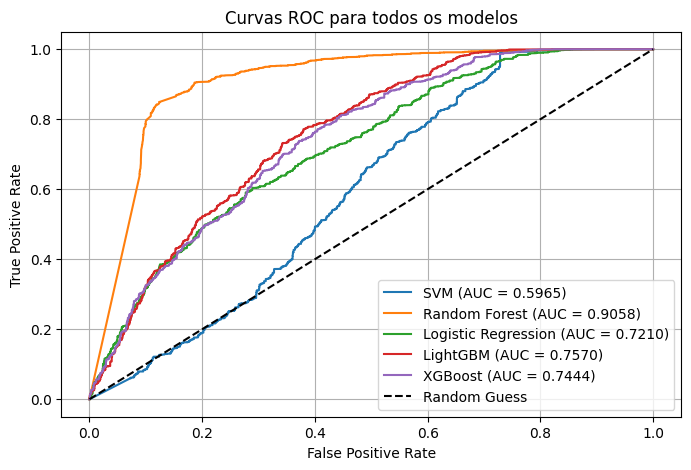

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import joblib

# Carregar modelos treinados (substitua o caminho do arquivo conforme necessário)
models = {
     "SVM": joblib.load("svm_model.pkl"),
     "Random Forest": joblib.load("random_forest_model.pkl"),
     "Logistic Regression": joblib.load("logistic_regression_model.pkl"),
     "LightGBM": joblib.load("lightgbm_model.pkl"),
     "XGBoost": joblib.load("xgboost_model.pkl")
 }

# Listas para armazenar informações para o gráfico consolidado
roc_curves = {}
auc_scores = {}

probabilities_df = pd.DataFrame()

# Agora você pode usar os modelos carregados para fazer previsões
for name, model in models.items():
    print(f"Fazendo previsões com o modelo: {name}")

    # Fazendo previsões no novo conjunto de dados (balanced_df)
    y_pred = model.predict(X_balanced)  # Previsão com o modelo calibrado

    # Calculando as probabilidades para a classe positiva (1)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_balanced)[:, 1]  # Probabilidade da classe positiva (1)
    else:
#         # Para SVM, que usa `decision_function` quando não tem `predict_proba`
        y_prob = model.decision_function(X_balanced)  # Retorna a margem da decisão, que pode ser usada como probabilidade

    # Adicionando as probabilidades ao DataFrame
    probabilities_df[name] = y_prob

#     # Acurácia
    accuracy = accuracy_score(y_balanced, y_pred)
    print(f"Acurácia para {name}: {accuracy:.4f}")

#     # Matriz de confusão
    print(f"\nMatriz de confusão para {name}:")
    print(confusion_matrix(y_balanced, y_pred))

#     # Relatório de classificação
    print(f"\nRelatório de classificação para {name}:")
    print(classification_report(y_balanced, y_pred))

     # Curva ROC e AUC
    fpr, tpr, thresholds = roc_curve(y_balanced, y_prob)
    auc = roc_auc_score(y_balanced, y_prob)

#     # Armazenando as curvas ROC para o gráfico consolidado
    roc_curves[name] = (fpr, tpr)
    auc_scores[name] = auc


# Criando o gráfico consolidado das curvas ROC
plt.figure(figsize=(8, 5))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_scores[name]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')  # Linha diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC para todos os modelos')
plt.legend(loc='lower right')
plt.grid()
plt.show()

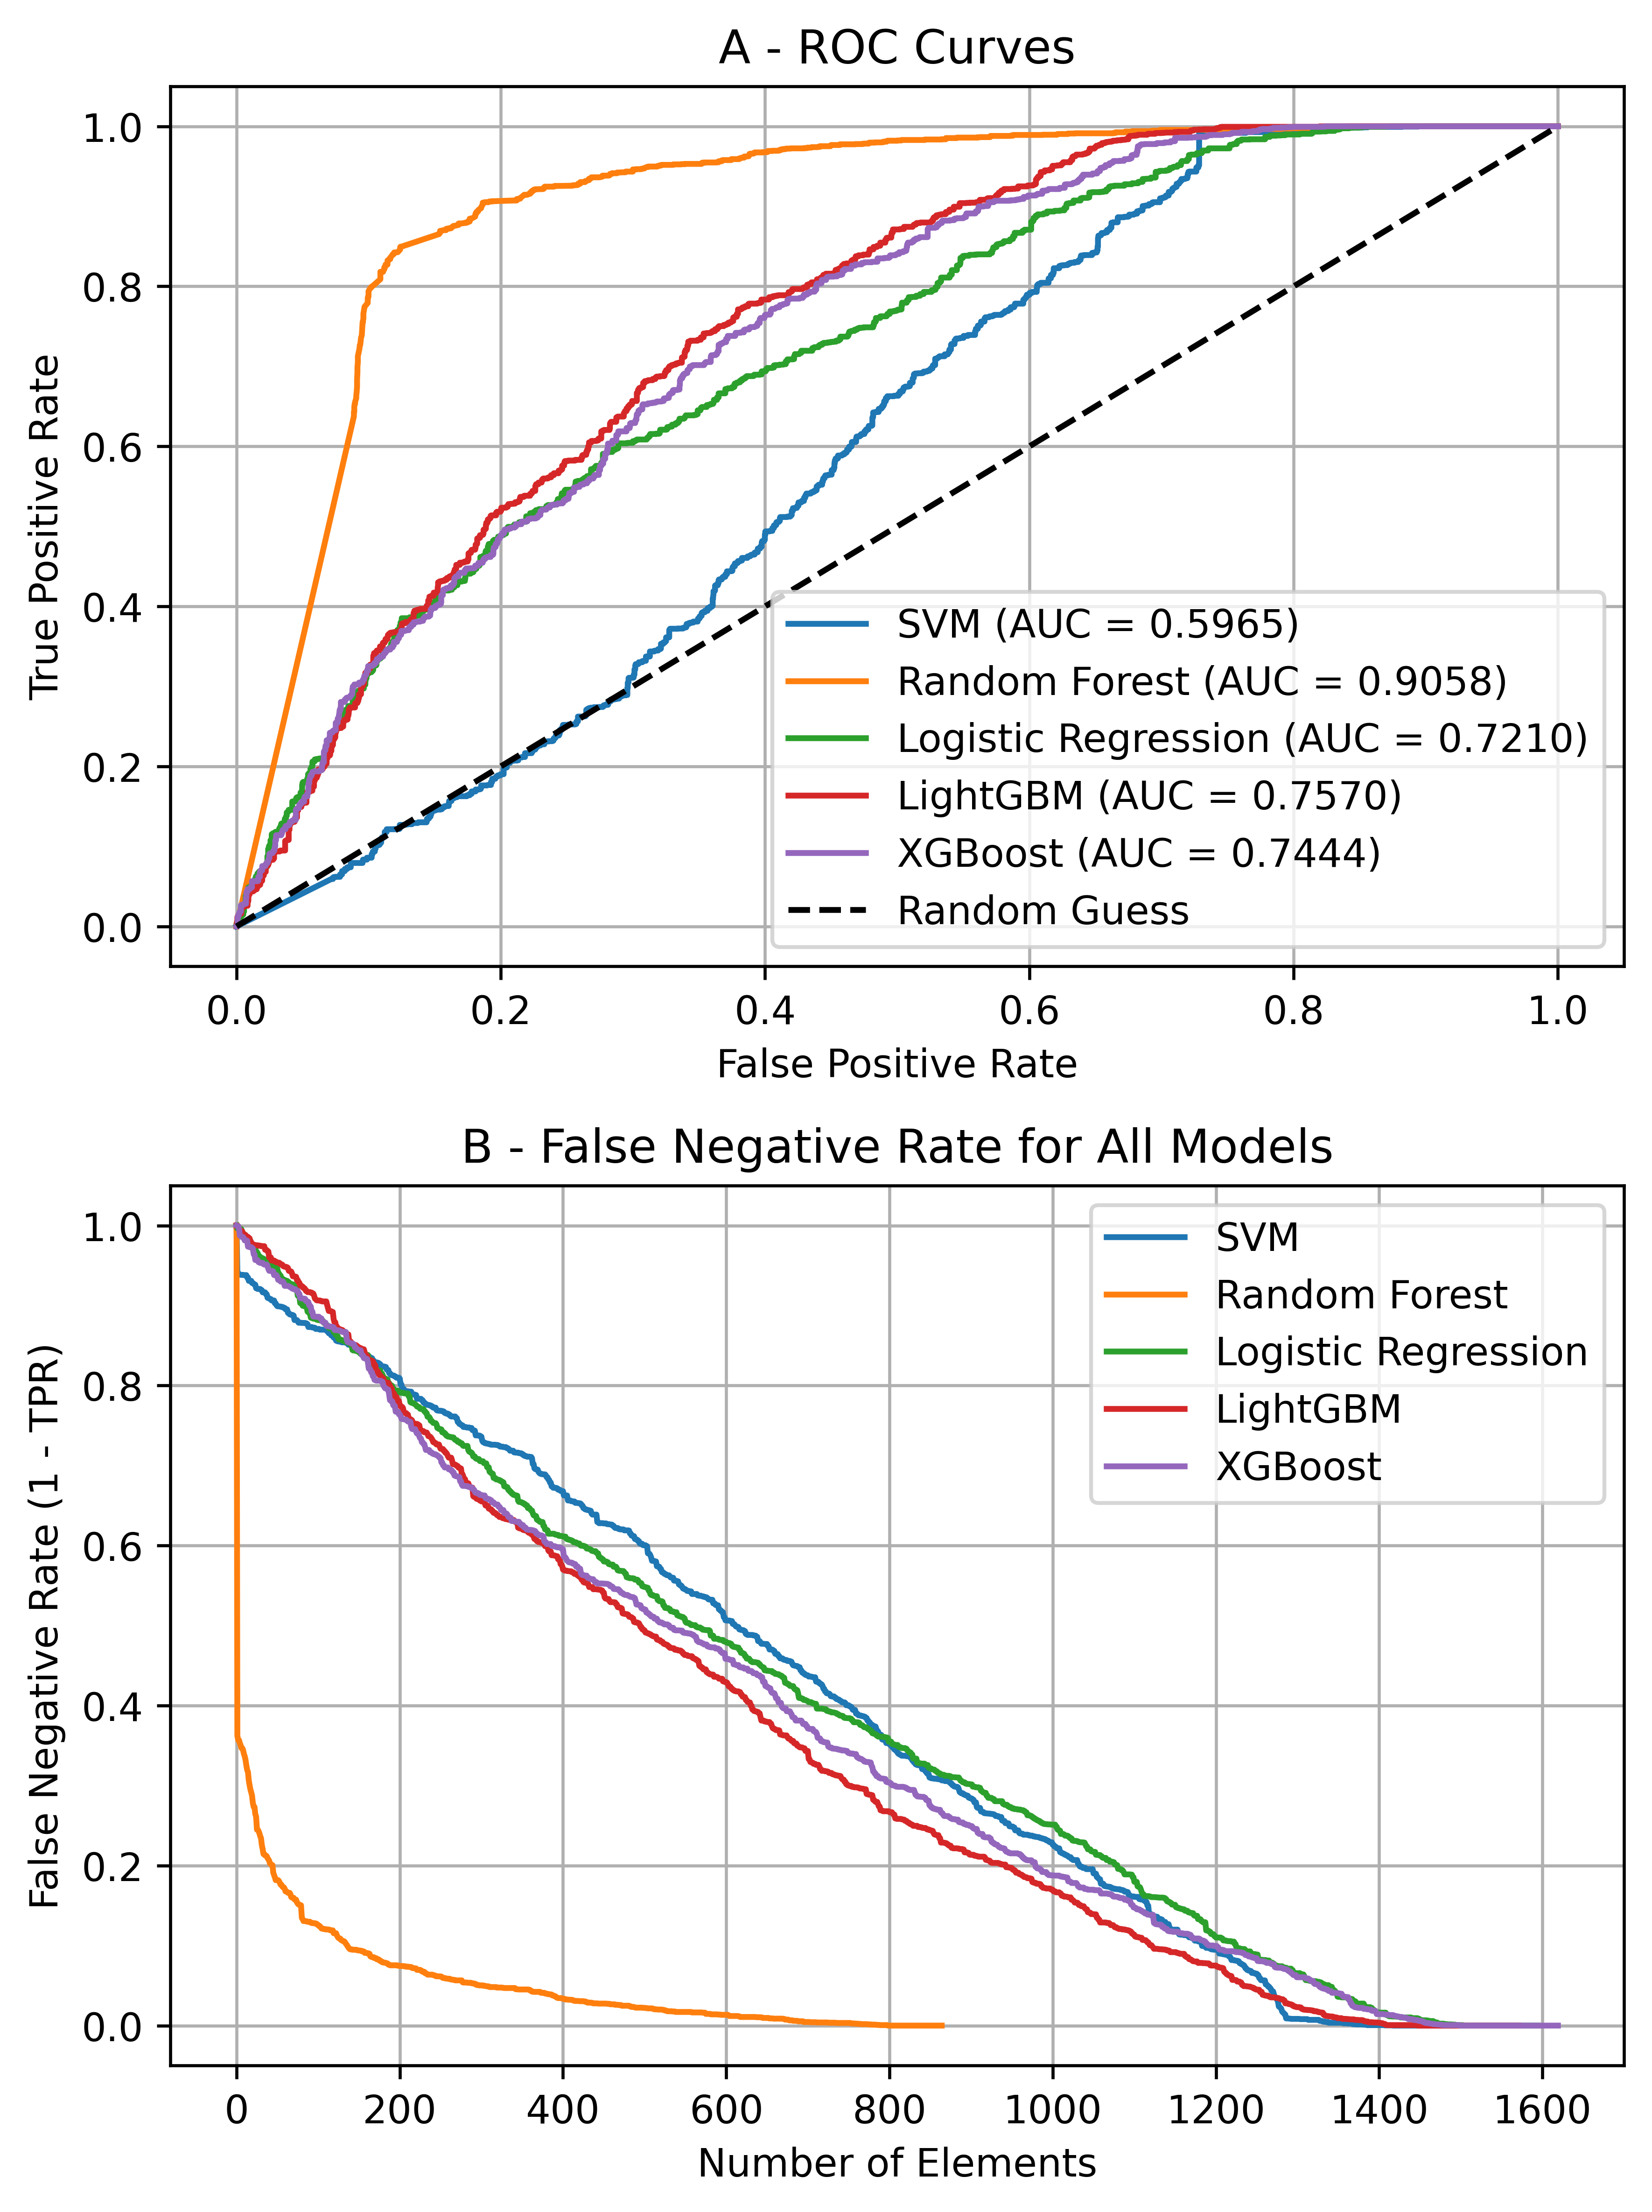

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com dois subplots um em cima do outro
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 8), dpi=600)

# --- Subplot 1: ROC Curves ---
for name, (fpr, tpr) in roc_curves.items():
    axs[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_scores[name]:.4f})')

axs[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate')
axs[0].set_title('A - ROC Curves')
axs[0].legend(loc='lower right')
axs[0].grid(True)

# --- Subplot 2: False Negative Rate (FNR) ---
for name, (fpr, tpr) in roc_curves.items():
    fnr = 1 - tpr
    axs[1].plot(range(len(fnr)), fnr, label=name)

axs[1].set_xlabel('Number of Elements')
axs[1].set_ylabel('False Negative Rate (1 - TPR)')
axs[1].set_title('B - False Negative Rate for All Models')
axs[1].legend()
axs[1].grid(True)

# Ajustar espaçamento entre os subplots
plt.tight_layout()

# Salvar a figura com 600 DPI
plt.savefig('roc_fnr_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

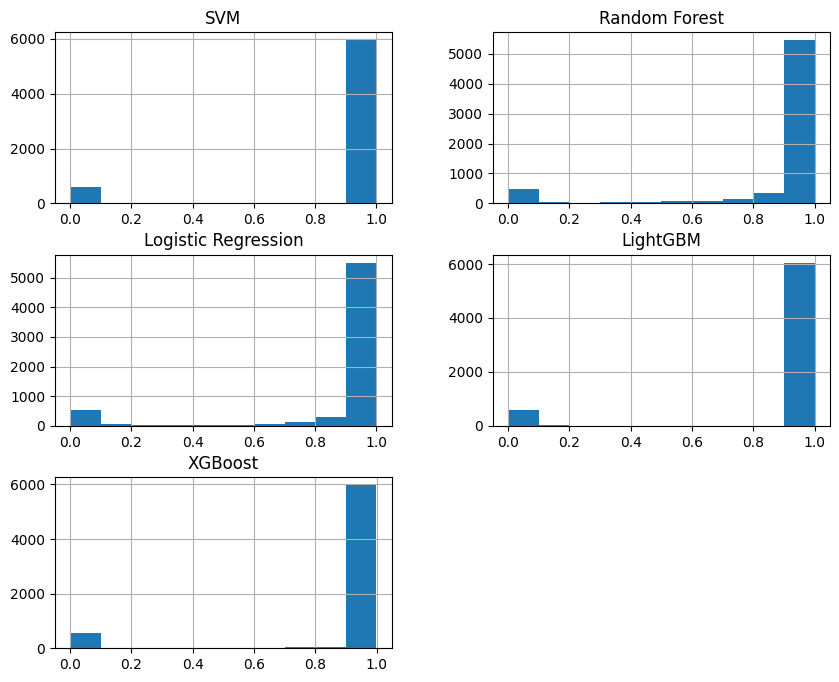

In [ ]:
 probabilities_df.hist(figsize=(10, 8))
 plt.show

In [ ]:
probabilities_df

,SVM,Random Forest,Logistic Regression,LightGBM,XGBoost
0,0.0001,0.1225,0.0346,0.0002,0.0035
1,0.0000,0.0043,0.0000,0.0000,0.0001
2,1.0000,1.0000,0.9997,1.0000,0.9998
3,0.9936,1.0000,0.8526,1.0000,0.9982
4,1.0000,1.0000,0.9998,1.0000,0.9995
...,...,...,...,...,...
6683,1.0000,1.0000,0.9726,1.0000,0.9988
6684,1.0000,1.0000,1.0000,1.0000,0.9998
6685,1.0000,1.0000,0.9998,1.0000,0.9997
6686,1.0000,1.0000,0.9909,1.0000,0.9997


In [ ]:
points_FC_downsampled

,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,...,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,cluster,occ
0,457146,POINT (571372.877 7455965.944),2.0000,1.0000,4.0000,6.0000,7.0000,5.0000,1.0000,2.0000,...,0.8424,0.2794,-0.1704,-0.0568,0.3969,-0.5411,-0.0566,-0.1394,2,0.0000
1,247713,POINT (570037.877 7455155.944),2.0000,1.0000,7.0000,7.0000,4.0000,3.0000,1.0000,1.0000,...,1.5242,0.1503,0.6519,-0.1808,0.1395,-0.0144,0.1998,0.1465,2,0.0000
2,615007,POINT (572377.877 7455585.944),4.0000,2.0000,2.0000,1.0000,6.0000,7.0000,3.0000,5.0000,...,-0.5324,0.4813,-0.6017,-0.3586,0.2330,-0.1193,-0.1894,0.1879,0,1.0000
3,612449,POINT (572362.877 7456600.944),1.0000,2.0000,1.0000,1.0000,2.0000,8.0000,8.0000,8.0000,...,-0.9361,0.7516,0.7706,-1.0379,-0.1368,0.7598,-0.1960,-0.4721,1,1.0000
4,631553,POINT (572482.877 7455280.944),4.0000,2.0000,5.0000,6.0000,6.0000,4.0000,4.0000,2.0000,...,0.0423,-0.1395,-0.6645,-0.1833,-0.0514,-0.2814,0.3734,-0.3578,0,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6683,126738,POINT (569267.877 7455580.944),6.0000,2.0000,3.0000,5.0000,2.0000,2.0000,6.0000,7.0000,...,-0.4165,-0.4623,0.6374,0.7454,0.2759,0.1385,0.7676,0.1963,3,1.0000
6684,414552,POINT (571102.877 7456985.944),4.0000,2.0000,5.0000,5.0000,4.0000,3.0000,3.0000,6.0000,...,0.1284,-0.3178,-0.6480,-0.0218,0.7229,0.0260,0.1297,-0.8921,0,1.0000
6685,493120,POINT (571602.877 7456645.944),6.0000,2.0000,3.0000,7.0000,3.0000,2.0000,4.0000,6.0000,...,-0.3628,-0.3571,-0.2513,-0.6470,-0.0443,-0.0944,0.6802,0.3073,0,1.0000
6686,499413,POINT (571642.877 7456580.944),6.0000,2.0000,1.0000,3.0000,8.0000,7.0000,5.0000,6.0000,...,-0.6535,0.6047,-0.1588,-0.4370,0.4236,-0.4021,0.1152,-0.0633,1,1.0000


In [ ]:
results = pd.concat([points_FC_downsampled, probabilities_df], axis=1)
results

,id,geometry,Soils,Lithology,TWI,Profile_Curvature,Plan_Curvature,Curvature,DEM,Slope,...,MCA6,MCA7,MCA8,cluster,occ,SVM,Random Forest,Logistic Regression,LightGBM,XGBoost
0,457146,POINT (571372.877 7455965.944),2.0000,1.0000,4.0000,6.0000,7.0000,5.0000,1.0000,2.0000,...,-0.5411,-0.0566,-0.1394,2,0.0000,0.0001,0.1225,0.0346,0.0002,0.0035
1,247713,POINT (570037.877 7455155.944),2.0000,1.0000,7.0000,7.0000,4.0000,3.0000,1.0000,1.0000,...,-0.0144,0.1998,0.1465,2,0.0000,0.0000,0.0043,0.0000,0.0000,0.0001
2,615007,POINT (572377.877 7455585.944),4.0000,2.0000,2.0000,1.0000,6.0000,7.0000,3.0000,5.0000,...,-0.1193,-0.1894,0.1879,0,1.0000,1.0000,1.0000,0.9997,1.0000,0.9998
3,612449,POINT (572362.877 7456600.944),1.0000,2.0000,1.0000,1.0000,2.0000,8.0000,8.0000,8.0000,...,0.7598,-0.1960,-0.4721,1,1.0000,0.9936,1.0000,0.8526,1.0000,0.9982
4,631553,POINT (572482.877 7455280.944),4.0000,2.0000,5.0000,6.0000,6.0000,4.0000,4.0000,2.0000,...,-0.2814,0.3734,-0.3578,0,1.0000,1.0000,1.0000,0.9998,1.0000,0.9995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6683,126738,POINT (569267.877 7455580.944),6.0000,2.0000,3.0000,5.0000,2.0000,2.0000,6.0000,7.0000,...,0.1385,0.7676,0.1963,3,1.0000,1.0000,1.0000,0.9726,1.0000,0.9988
6684,414552,POINT (571102.877 7456985.944),4.0000,2.0000,5.0000,5.0000,4.0000,3.0000,3.0000,6.0000,...,0.0260,0.1297,-0.8921,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.9998
6685,493120,POINT (571602.877 7456645.944),6.0000,2.0000,3.0000,7.0000,3.0000,2.0000,4.0000,6.0000,...,-0.0944,0.6802,0.3073,0,1.0000,1.0000,1.0000,0.9998,1.0000,0.9997
6686,499413,POINT (571642.877 7456580.944),6.0000,2.0000,1.0000,3.0000,8.0000,7.0000,5.0000,6.0000,...,-0.4021,0.1152,-0.0633,1,1.0000,1.0000,1.0000,0.9909,1.0000,0.9997


In [ ]:
results.to_file("results_MSD.shp", driver="ESRI Shapefile")